In [1]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

import mbloodmoon as bm
from mbloodmoon.mask import codedmask
from mbloodmoon.types import CoordEquatorial
from mbloodmoon.images import argmax
import mbloodmoon.iros_management as iros

from _IROS_support import _handle_dirpaths

def enhance_slices(
    sky: NDArray,
    pos: tuple[int, int] | None,
    crp: tuple[int, int] | None,
    ylim: tuple[int, int] | None,
) -> None:
    """
    """
    cropped_A = iros.crop(sky, pos, crp, False)
    xslice_A, yslice_A = cropped_A[crp[0], :], cropped_A[:, crp[1]]

    fig, axs = plt.subplots(1, 2, figsize=(13, 6))
    fig.tight_layout()
    xs = tuple(np.arange(len(s)) - len(s) // 2 for s in (xslice_A, yslice_A))
    for ax, x, y, s in zip(axs, xs, (xslice_A, yslice_A), ('x', 'y')):
        ax.plot(x, y)
        ax.set_title(f'{s} slice', fontsize=14, pad=8, fontweight='bold')
        ax.set_ylim(ylim)
        ax.set_xlabel("index", fontsize=12, fontweight='bold')
        ax.set_ylabel("counts", fontsize=12, fontweight='bold')
        ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2, alpha=0.70)
        ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')
        ax.ticklabel_format(scilimits=(-3, 4))
    plt.show()


mask_FITS = "wfm_mask.fits"

skyfield = "IROSDummy"
data_FITS = "catalog_noCXB_1Crab_infdet_2-50keV_1ks"

N_TEST = "BMRESIDUALS_test_s4_upx1y1_detected"

UPX, UPY = 1, 1

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    test_name=N_TEST,
)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = "detected"

filepaths = bm.simulation_files(simul_data)
energy_range = (None, None)
s0 = CoordEquatorial(ra=223.438453172364, dec=-22.0306369561417)
s1 = CoordEquatorial(ra=231.465619039524, dec=-24.3850523670622)
s2 = CoordEquatorial(ra=241.426574413659, dec=-26.6219960573764)
s3 = CoordEquatorial(ra=253.284954989872, dec=-28.3032728404397)
s4 = CoordEquatorial(ra=266.4, dec=-28.94)
s5 = CoordEquatorial(ra=266.4, dec=-17.3775096005863)
s6 = CoordEquatorial(ra=266.4, dec=-6.63642699386322)
s7 = CoordEquatorial(ra=266.4, dec=2.68547284486862)
s8 = CoordEquatorial(ra=266.4, dec=10.4607609542733)
coords = (
    s0, s1, s2, s3, s5, s6, s7, s8,
)
assert (s4 not in coords) and (len(coords) == 8)


wfm = codedmask(mask_path, UPX, UPY)
sdlA = bm.simulation(filepaths[cam_a][dataset], energy_range=energy_range, coords=coords)
sdlB = bm.simulation(filepaths[cam_b][dataset], energy_range=energy_range, coords=coords)

catalogA = bm.simulation(filepaths[cam_a]["sources"])
catalogB = bm.simulation(filepaths[cam_b]["sources"])

In [2]:
mask_path, simul_data, save_path, len(sdlA.data)

('/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/wfm_mask.fits',
 '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/IROSDummy/catalog_noCXB_1Crab_infdet_2-50keV_1ks/',
 '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Outputs/OutIROSDummy/catalog_noCXB_1Crab_infdet_2-50keV_1ks/BMRESIDUALS_test_s4_upx1y1_detected/',
 113012)

In [3]:
database_name = save_path + f"IROS_sources_database_TEST_{N_TEST}.fits"
database = iros.load_iros_data(database_name)

# Loading data...
# Loading completed!


# Loading data...
# Loading completed!


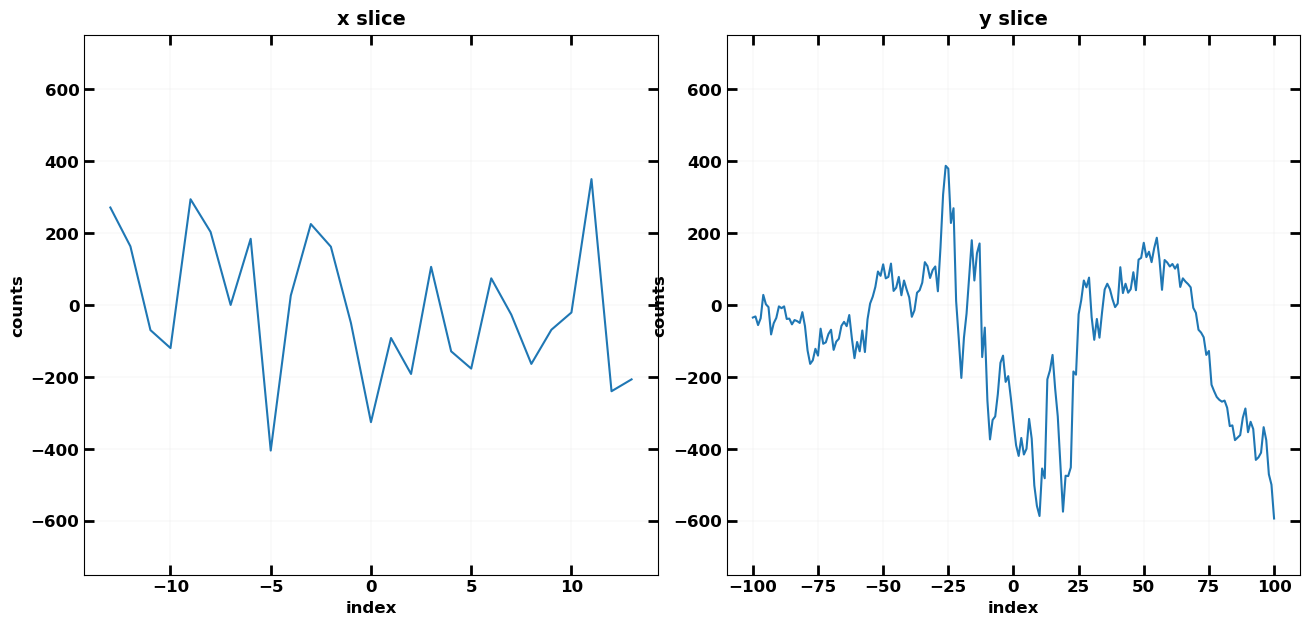

In [4]:
res_sky_camA, _ = iros.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{N_TEST}.fits")

crp = (int(50 * (1 + UPY)), int(10 * (1 + UPX / 3)))

enhance_slices(
    sky=res_sky_camA,
    pos=(database[cam_a]["y"]["data"][0], database[cam_a]["x"]["data"][0]),
    crp=crp,
    ylim=(-750, 750),
)

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


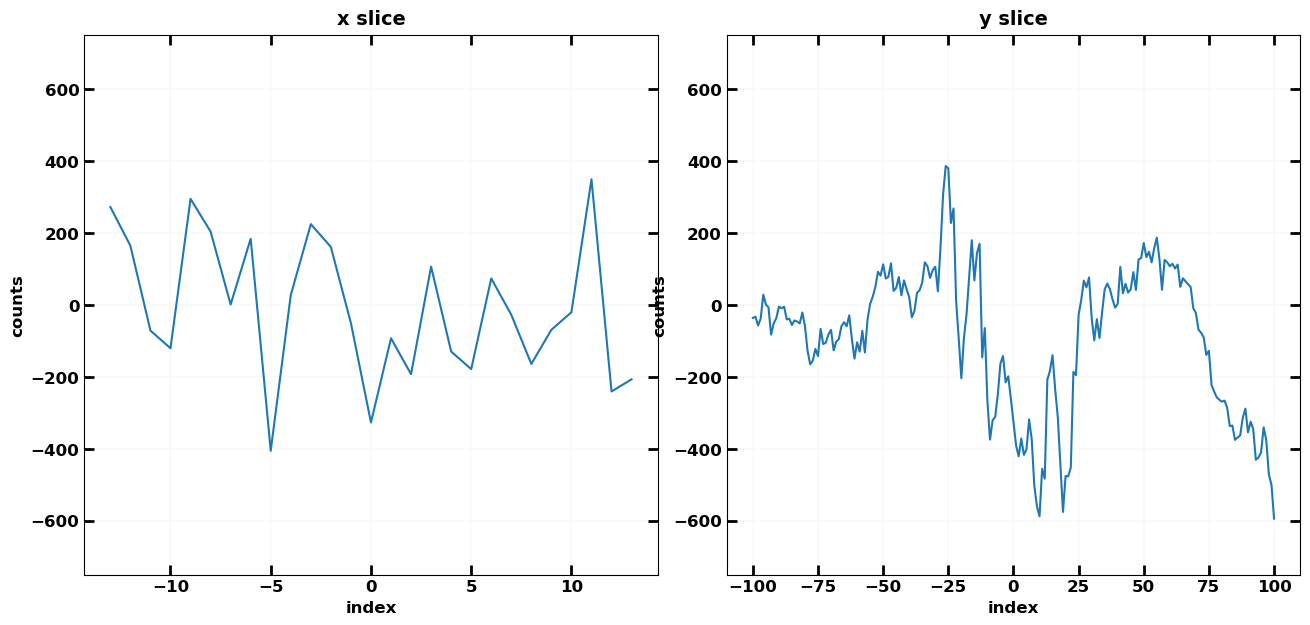

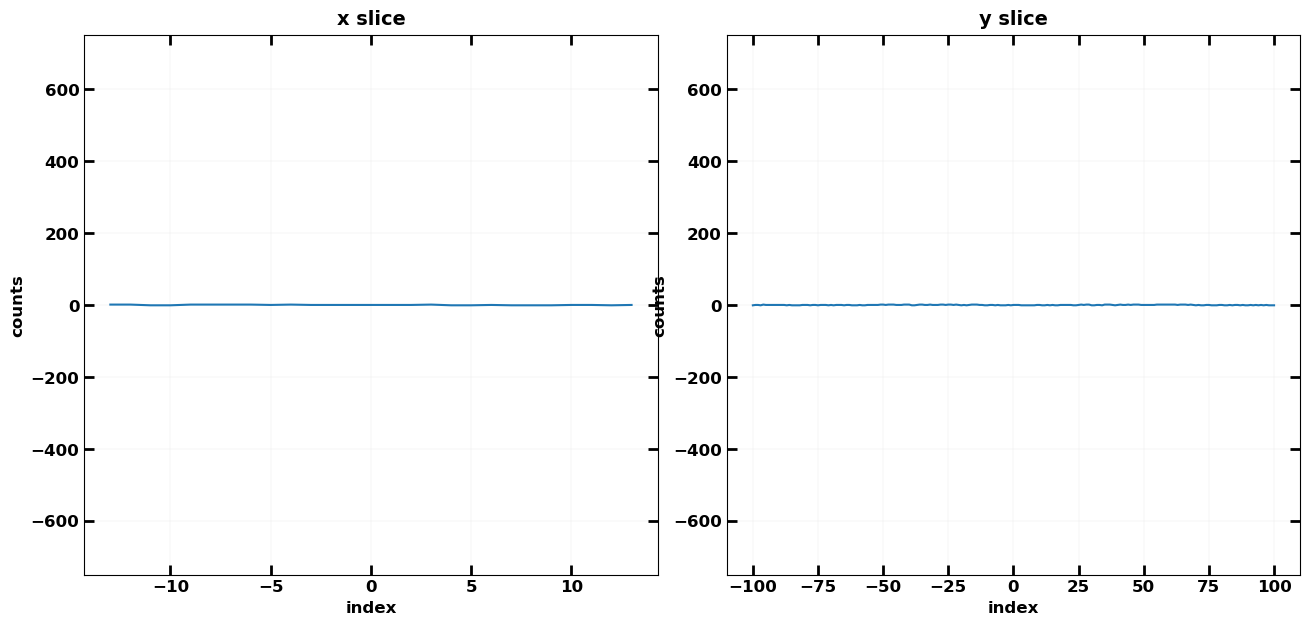

In [5]:
simul_sky_camA, _ = iros.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
sky_camA, _ = iros.load_sky(save_path + f"OUTsky_IROS_CAM1A_TEST_{N_TEST}.fits")

crp = (int(50 * (1 + UPY)), int(10 * (1 + UPX / 3)))

from mbloodmoon.optim import model_sky

sx, sy, f = tuple(database[cam_a][key]["data"][0] for key in ('shift_x', 'shift_y', 'fluence'))
modeled_sky_camA = model_sky(wfm, sx, sy, f, vignetting=True, psfy=False)

enhance_slices(
    sky=simul_sky_camA - modeled_sky_camA,
    pos=(database[cam_a]["y"]["data"][0], database[cam_a]["x"]["data"][0]),
    crp=crp,
    ylim=(-750, 750),
)

enhance_slices(
    sky=simul_sky_camA - iros.make_sky(database, cam_a, wfm, res_sky_camA, vignetting=True, psfy=False),
    pos=(database[cam_a]["y"]["data"][0], database[cam_a]["x"]["data"][0]),
    crp=crp,
    ylim=(-750, 750),
)

In [6]:
type(res_sky_camA[0, 0]), res_sky_camA[0, 0], np.float32(res_sky_camA[0, 0])

(numpy.int32, np.int32(-1), np.float32(-1.0))

In [ ]:
from copy import deepcopy

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from pandas import DataFrame

from mbloodmoon.coords import equatorial2shift, shift2angle
from mbloodmoon.io import SimulationDataLoader
from mbloodmoon.mask import CodedMaskCamera, codedmask
from mbloodmoon.optim import model_sky
import mbloodmoon.iros_management as iros

from _IROS_support import _handle_dirpaths

def plot_sequence(
    input_sequence: list,
    title: list[str],
    label: list = None,
    x: list = None,
    xlabel: list[str] = None,
    ylabel: list[str] = None,
    color: list[tuple[str, str]] = None,
    style: list[str] = None,
    offsetx: list[tuple[float, float]] = None,
    offsety: list[tuple[float, float]] = None,
    save_to: str = None,
) -> None:

    def _handle_subplots(nplots, spacing=0.27):
        """Creates and configures subplots."""
        size = 6
        fig_size = (size * nplots + 1, size) if nplots > 1 else (size, size)
        fig, axes = plt.subplots(1, nplots, figsize=fig_size)
        fig.tight_layout()
        fig.subplots_adjust(wspace=spacing * 5 / size)
        return fig, (axes if nplots > 1 else [axes])

    def _set_labels(ax, xlabel, ylabel, title):
        """Configures labels and titles."""
        ax.set_xlabel(xlabel or "", fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel or "", fontsize=12, fontweight='bold')
        ax.set_title(title, fontsize=14, pad=8, fontweight='bold')

    def _set_ticks(ax):
        """Configures grid and tick properties."""
        ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2, alpha=0.70)
        ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')
        ax.ticklabel_format(scilimits=(-3, 4))

    nplots = len(input_sequence)
    x = x or [None] * nplots
    label = label or [None] * nplots
    xlabel = xlabel or [None] * nplots
    ylabel = ylabel or [None] * nplots
    color = color or [('OrangeRed', 'r')] * nplots
    style = style or ['bar'] * nplots
    offsetx = offsetx or [(None, None)] * nplots
    offsety = offsety or [(None, None)] * nplots

    fig, axes = _handle_subplots(nplots)
    for i, ax in enumerate(axes):
        x_values = x[i] if x[i] is not None else np.arange(len(input_sequence[i]))

        if isinstance(input_sequence[i], tuple):
            for idx in range(len(input_sequence[i])):
                fcolor, ecolor = color[i][idx]
                #ax.bar(x_values, input_sequence[i][idx], width=1, facecolor=fcolor,
                #       edgecolor=ecolor, linewidth=1, alpha=0.50, label=label[i][idx])
                ax.plot(x_values, input_sequence[i][idx], c=ecolor, alpha=0.75, label=label[i][idx])
                #ax.scatter(x_values, input_sequence[i][idx], facecolor=fcolor, edgecolors=ecolor,
                #           s=30, alpha=0.8, linewidths=1.5, label=label[i][idx])
        else:
            fcolor, ecolor = color[i]
            if style[i] == 'scatter':
                ax.plot(x_values, input_sequence[i], c=fcolor, alpha=0.75)
                #ax.scatter(x_values, input_sequence[i], facecolor=fcolor, edgecolors=ecolor,
                #           s=50, alpha=0.8, linewidths=1.5, label=label[i])
            else:
                ax.bar(x_values, input_sequence[i], width=1, facecolor=fcolor,
                       edgecolor=ecolor, linewidth=1, alpha=0.70)

        ax.set_xlim(offsetx[i][0], offsetx[i][1])
        ax.set_ylim(offsety[i][0], offsety[i][1])
        _set_labels(ax, xlabel[i], ylabel[i], title[i])
        _set_ticks(ax)
        if label[i] is not None: ax.legend(loc='best')
    
    if save_to is not None: plt.savefig(save_to)
    plt.show()


def enhance_slices(
    sky: list[np.array],
    label: list,
    pos: tuple[int],
    crp: tuple[int] = (40, 40),
    source: str = None,
    cameraID: str = None,
    offsety_first: list[tuple[float, float]] = None,
    offsety_second: list[tuple[float, float]] = None,
    save_to_first: str = None,
    save_to_second: str = None,
) -> None:
    
    sky_A, sky_B = sky
    cropped_A = iros.crop(sky_A, pos, crp, False)
    xslice_A, yslice_A = cropped_A[crp[0], :], cropped_A[:, crp[1]]
    cropped_B = iros.crop(sky_B, pos, crp, False)
    xslice_B, yslice_B = cropped_B[crp[0], :], cropped_B[:, crp[1]]

    plot_sequence(
        input_sequence=[(xslice_A, xslice_B), (yslice_A, yslice_B)],
        title=[
            f"{source.upper() if source else "Source"} {ax}-axis Slice - {cameraID.upper() if cameraID else ""}"
            for ax in ("X", "Y")
        ],
        label=label,
        x=[np.arange(len(s)) - len(s) // 2 for s in (xslice_A, yslice_A)],
        xlabel=["x", "y"],
        ylabel=["counts", "counts"],
        color=[(('white', 'r'), ('white', 'DodgerBlue'))] * 2,
        offsety=offsety_first,
        save_to=save_to_first,
    )
    plot_sequence(
        input_sequence=[(xslice_A - xslice_B), (yslice_A - yslice_B)],
        title=[
            f"{source.upper() if source else "Source"} {ax}-axis Slice Residues - {cameraID.upper() if cameraID else ""}"
            for ax in ("X", "Y")
        ],
        x=[np.arange(len(s)) - len(s) // 2 for s in (xslice_A, yslice_A)],
        xlabel=["x", "y"],
        ylabel=["counts", "counts"],
        style=["scatter"] * 2,
        offsety=offsety_second,
        save_to=save_to_second,
    )


def upscale(
    data: NDArray,
    upscale_y: int = 1,
    upscale_x: int = 1,
) -> NDArray:
    """
    Upscales a 2D array by repeating elements along each axis and
    by interpolating array values.

    Args:
        data (NDArray): Input 2D array.
        upscale_y (int): Upscaling factor over the y direction.
        upscale_x (int): Upscaling factor over the x direction.

    Returns:
        output (NDArray): Oversampled array.

    Raises:
        ValueError: if upscale factors are not positive integers.
    
    Notes:
        - The array total sum is conserved through linear interpolation.
        - For N-dim arrays, consider using `astropy.nndata.block_replicate()`.
    """
    def enlarge(
        m: NDArray,
        upscale_f: tuple[int, int],
    ) -> NDArray:
        for i, f in enumerate(upscale_f[::-1]):
            m = np.repeat(m, f, axis=i)
        return m
    
    if not (
        (isinstance(upscale_y, int) and upscale_y > 0) and
        (isinstance(upscale_x, int) and upscale_x > 0)
    ):
        raise ValueError("Upscaling factors must be positive integers.")
    
    upscaling = (upscale_x, upscale_y)
    return enlarge(data, upscaling) / np.prod(upscaling)


def image_plot(
    arr: NDArray,
    title: str = None,
    xlabel: str = None,
    ylabel: str = None,
    cbarlabel: str = None,
    figsize: tuple[int | float] = (6, 6),
    dpi: int = 100,
    cbarscinot: bool = False,
    cbarloc: str = "right",
    **kwargs,
) -> None:
    """
    Plot the input 2D array.
    """
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    fig.tight_layout()
    fig.dpi = dpi

    img = ax.imshow(arr, origin='lower', **kwargs)
    cbar = fig.colorbar(img, ax=ax, location=cbarloc, shrink=0.75, pad=0.05)
    cbar.ax.tick_params(labelsize=11)
    if cbarlabel: cbar.set_label(cbarlabel, fontsize=12, fontweight='bold')
    if cbarscinot: cbar.formatter.set_powerlimits((-3, 3))

    ax.set_title(title, fontsize=14, pad=8, fontweight='bold')
    ax.set_xlabel(xlabel or "", fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel or "", fontsize=12, fontweight='bold')
    ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2, alpha=0.70)
    ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    plt.show()


def get_catalog_theta(
    data: dict,
    catalogs: tuple[np.recarray],
    sdls: tuple[SimulationDataLoader],
    camera: CodedMaskCamera,
) -> DataFrame:
    """Returns catalog sources respective camera angular coordinates."""
    db = {
        cameraID: deepcopy({
            "ID": [],
            "theta_x": [],
            "theta_y": [],
        })
        for cameraID in data.keys()
    }

    for sdl, cat, cameraID in zip(
        sdls, catalogs, data.keys(),
    ):
        print(f"# Checking {cameraID.upper()}...")
        for name in data[cameraID]["catalog_name"]["data"]:
            cat_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
            cat_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
            sx, sy = equatorial2shift(sdl, camera, cat_ra, cat_dec)
            db[cameraID]["ID"].append(name)
            db[cameraID]["theta_x"].append(shift2angle(camera, sx))
            db[cameraID]["theta_y"].append(shift2angle(camera, sy))

    return iros.dict2df(db)



mask_FITS = "wfm_mask.fits"
skyfield = "IROSDummy"
data_FITS = "catalog_noCXB_1Crab_infdet_2-50keV_1ks"

N_TEST = "BMRESIDUALS_test_sky_upx5y1_detected"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    test_name=N_TEST,
)

UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"

simul_sky_camA, _ = iros.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
simul_sky_camB, _ = iros.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
database = iros.load_iros_data(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


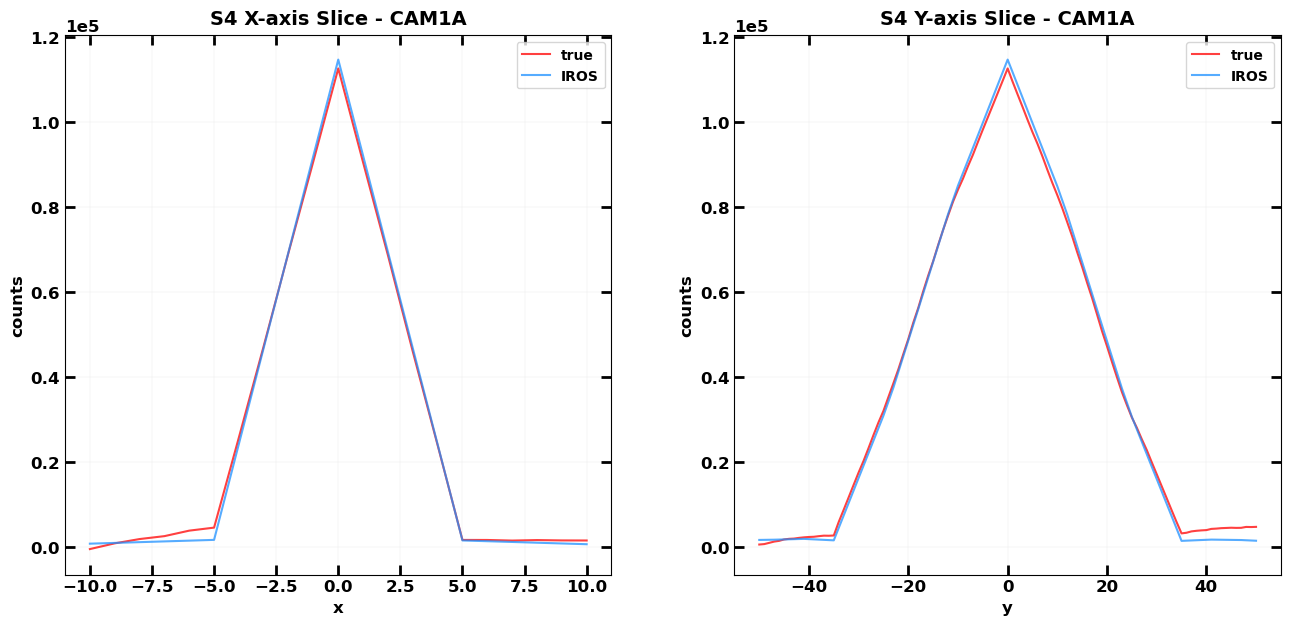

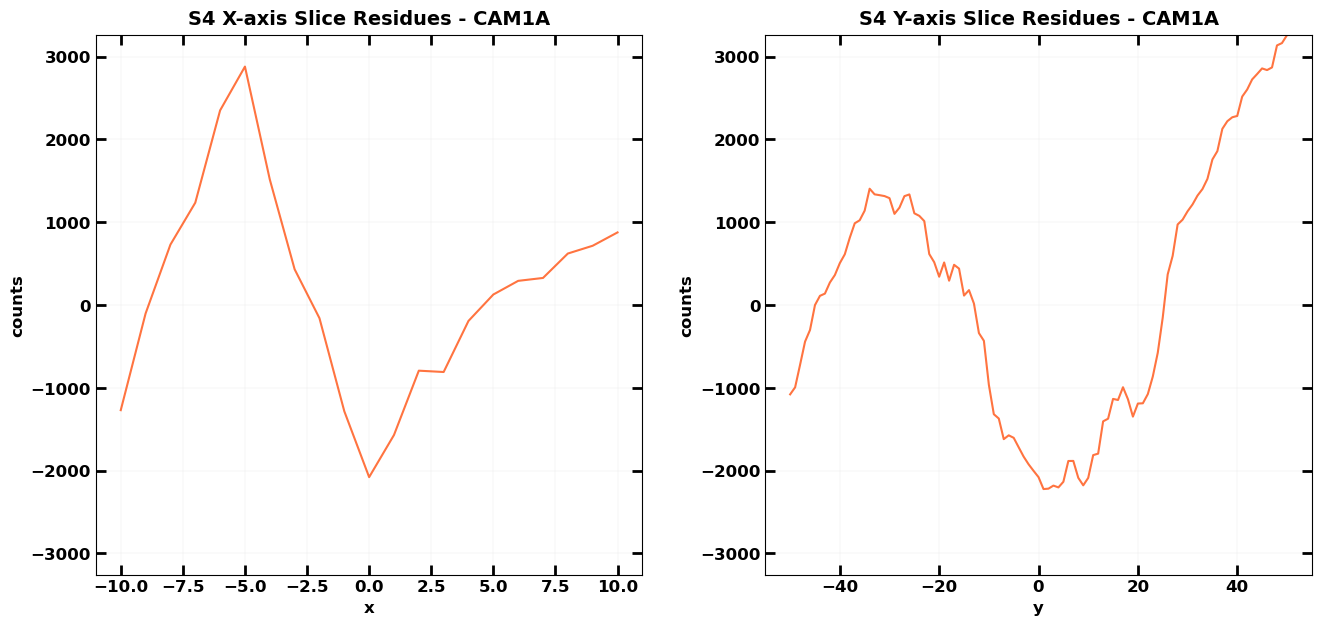

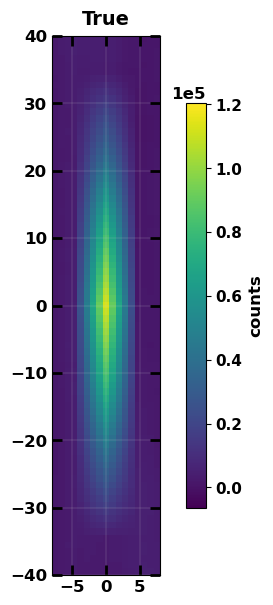

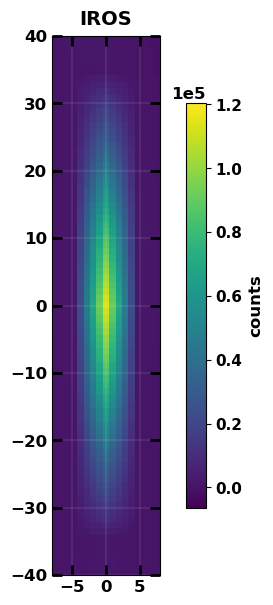

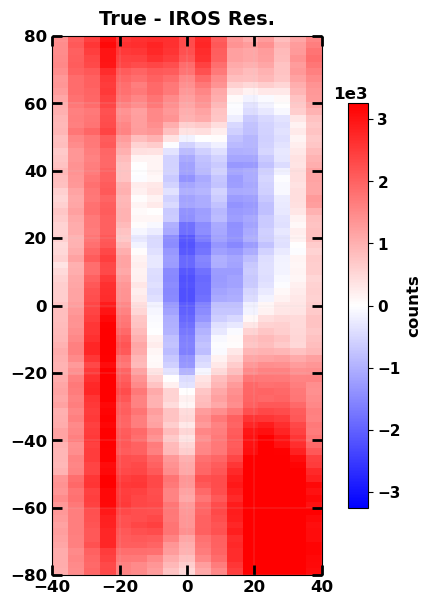

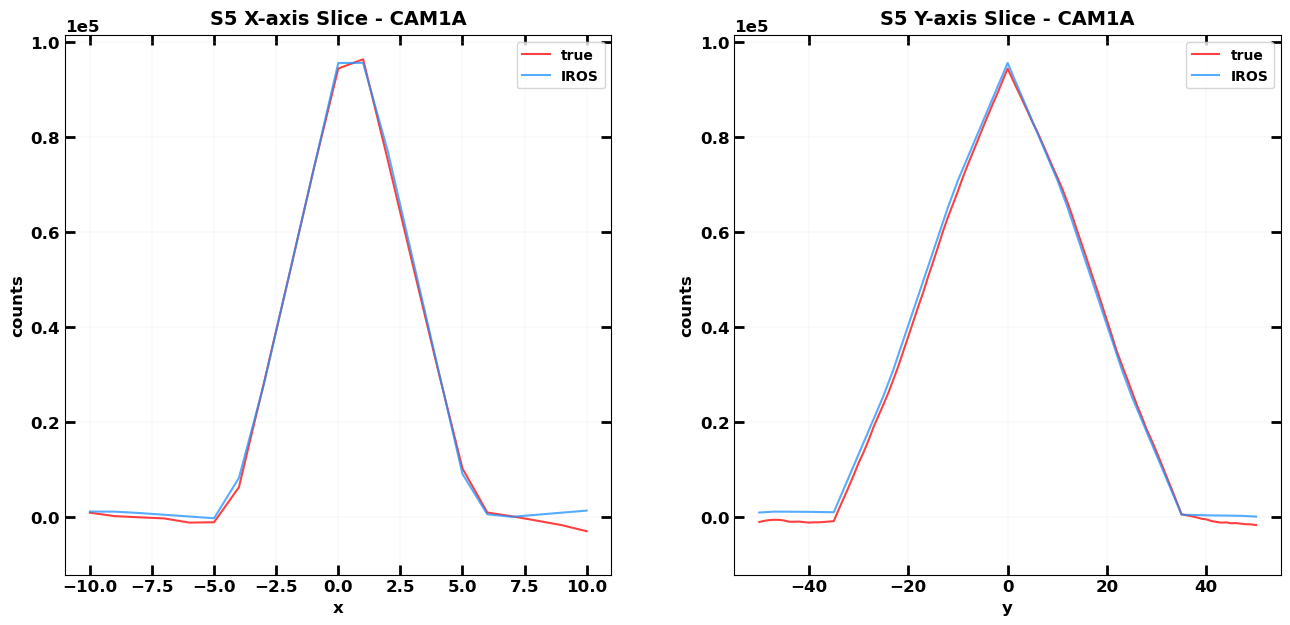

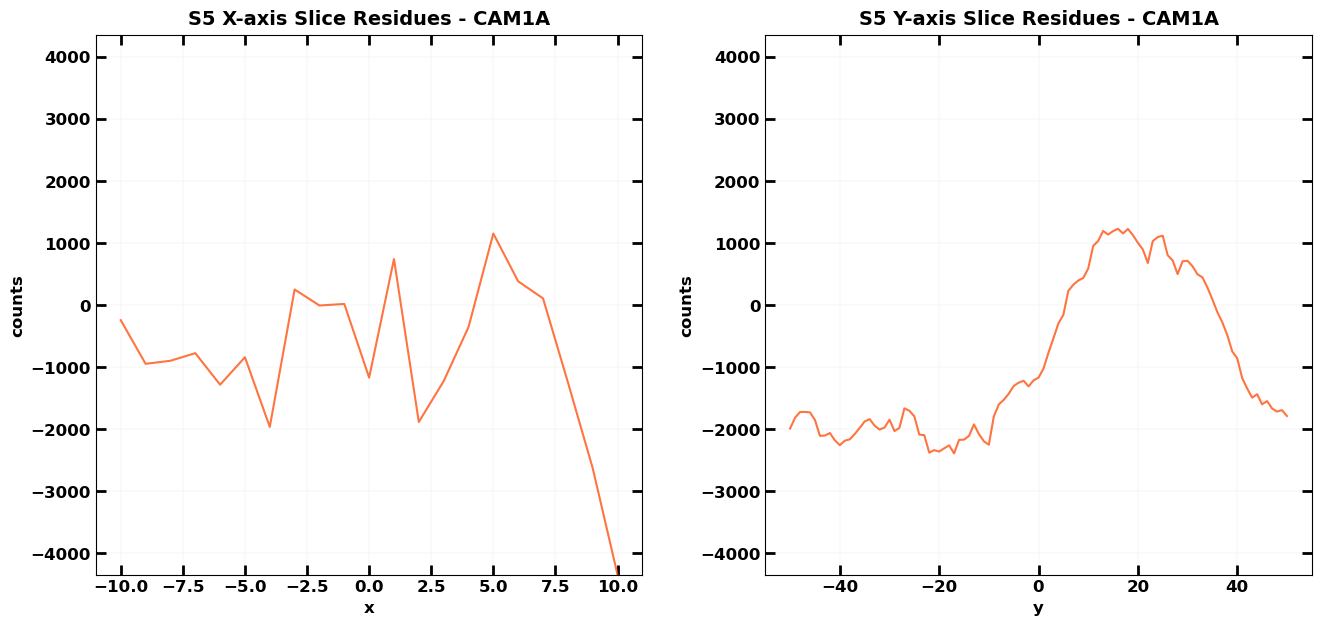

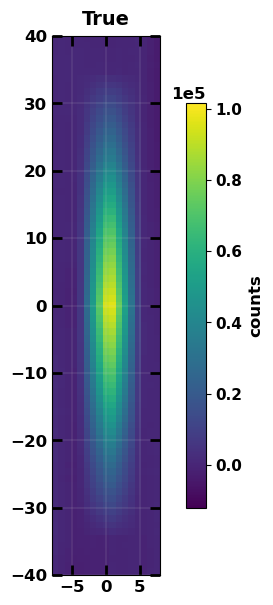

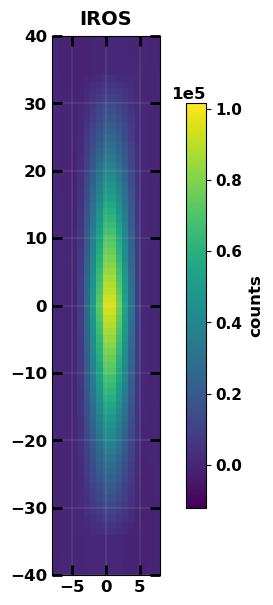

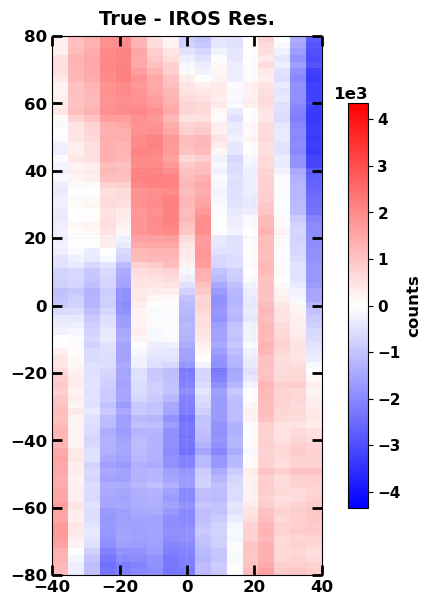

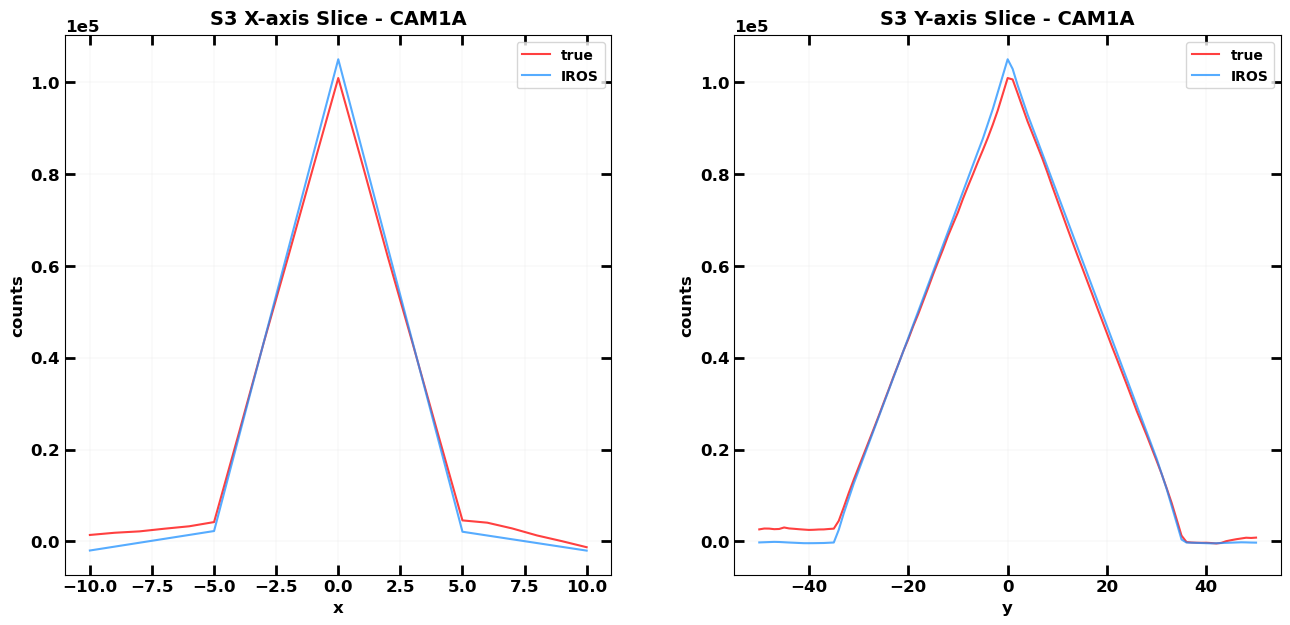

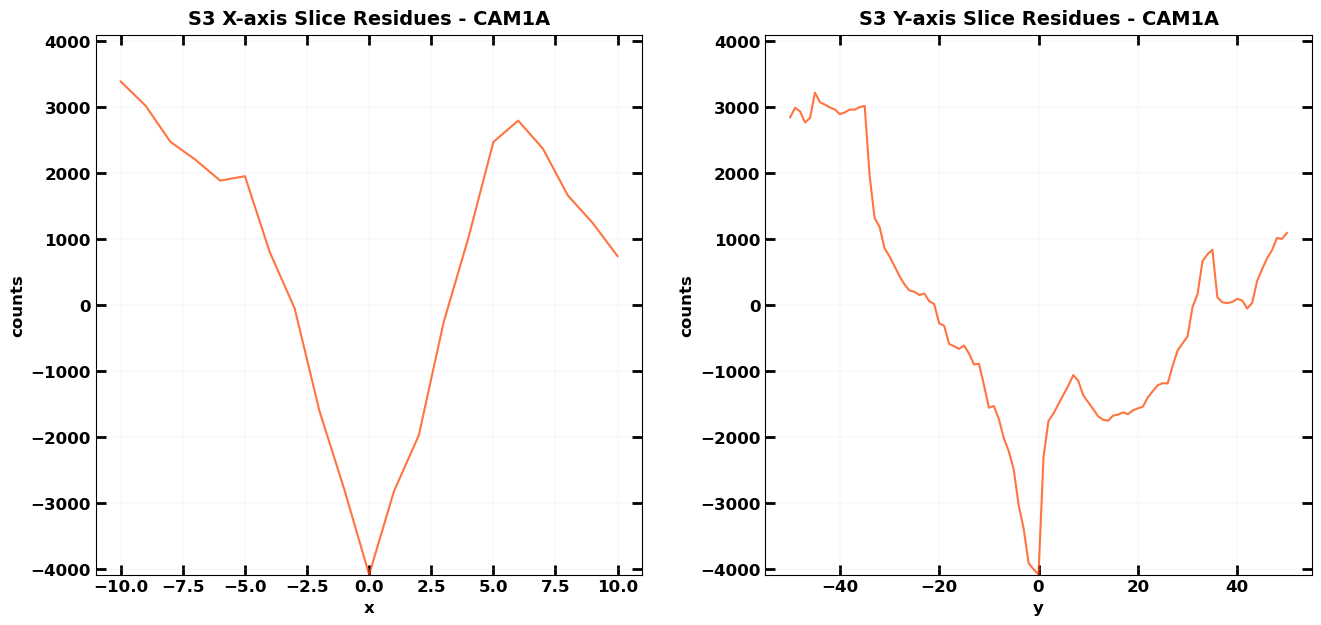

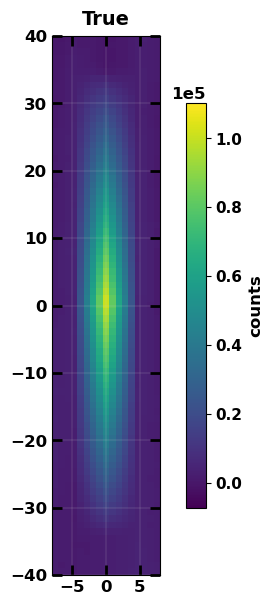

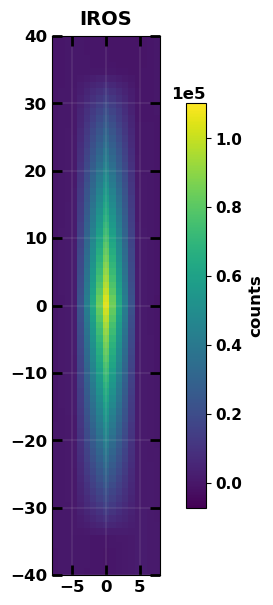

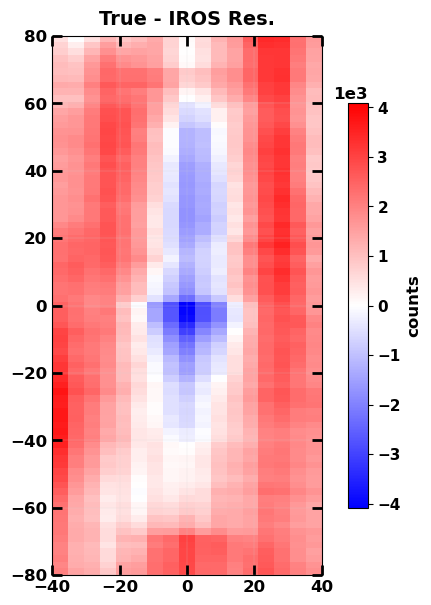

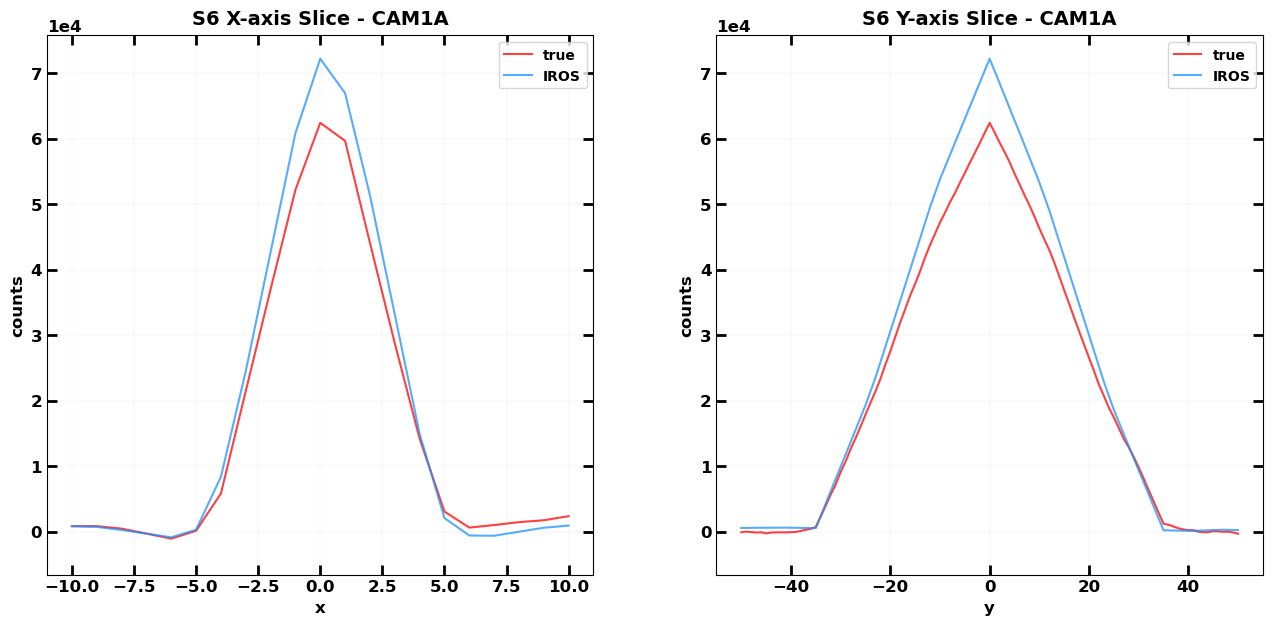

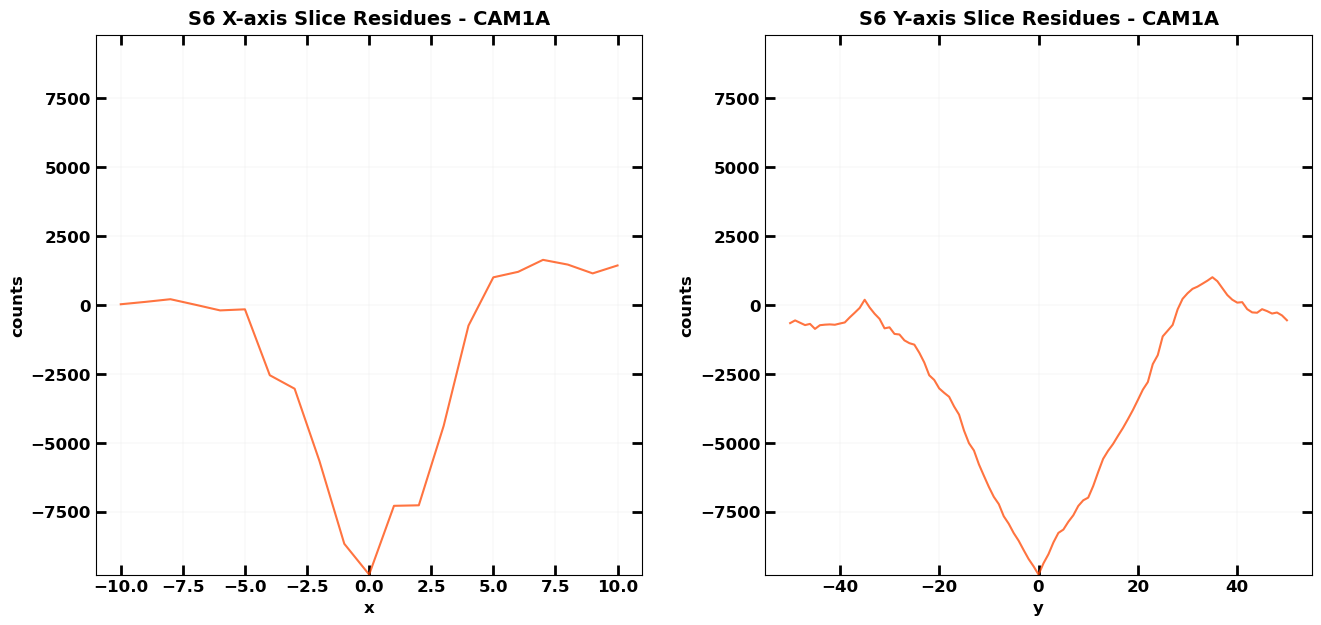

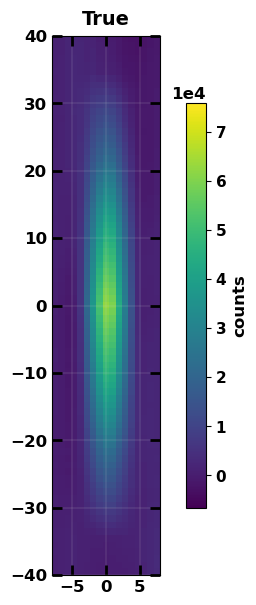

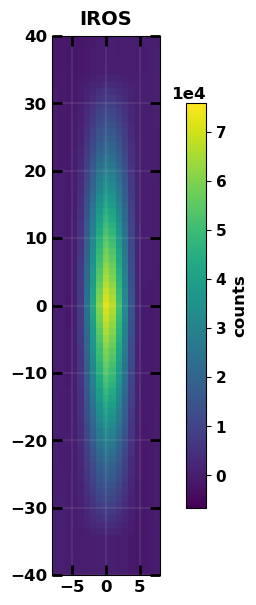

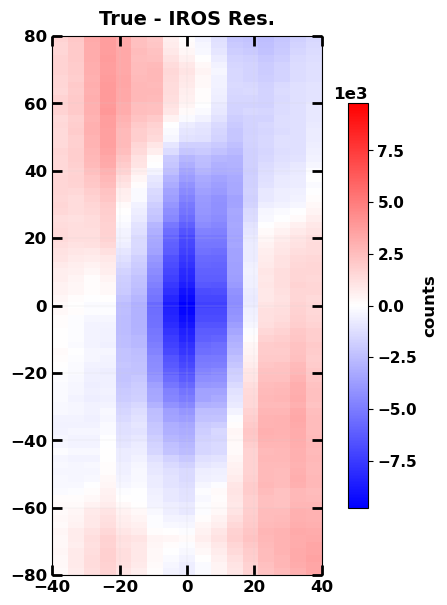

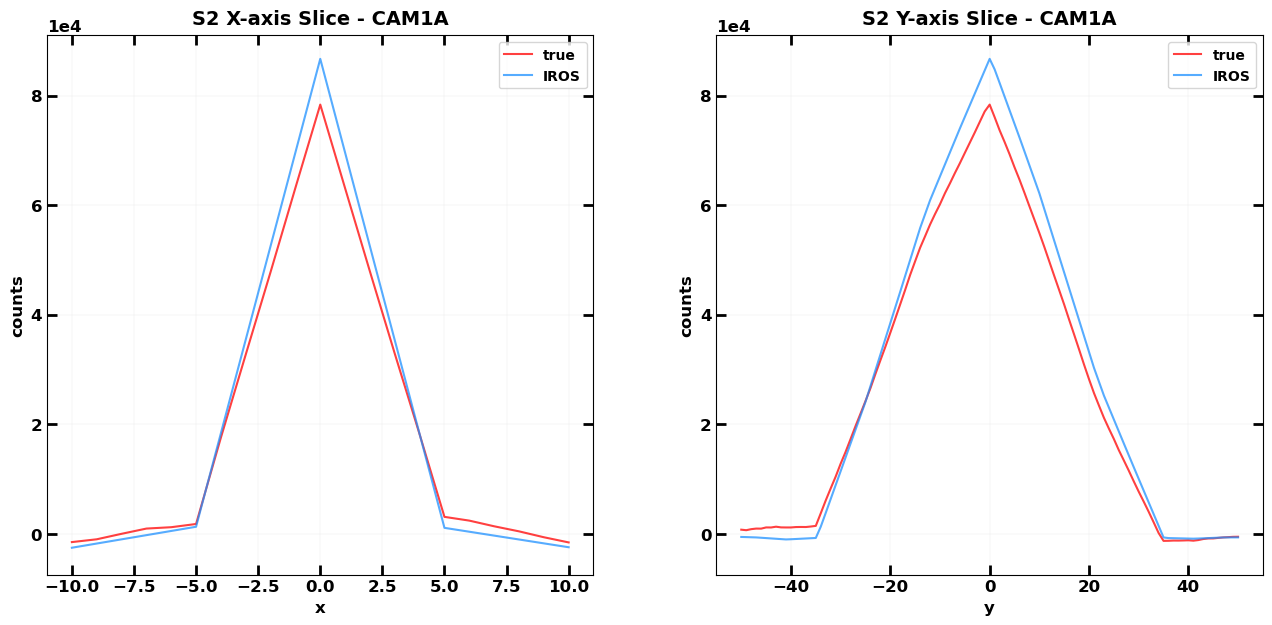

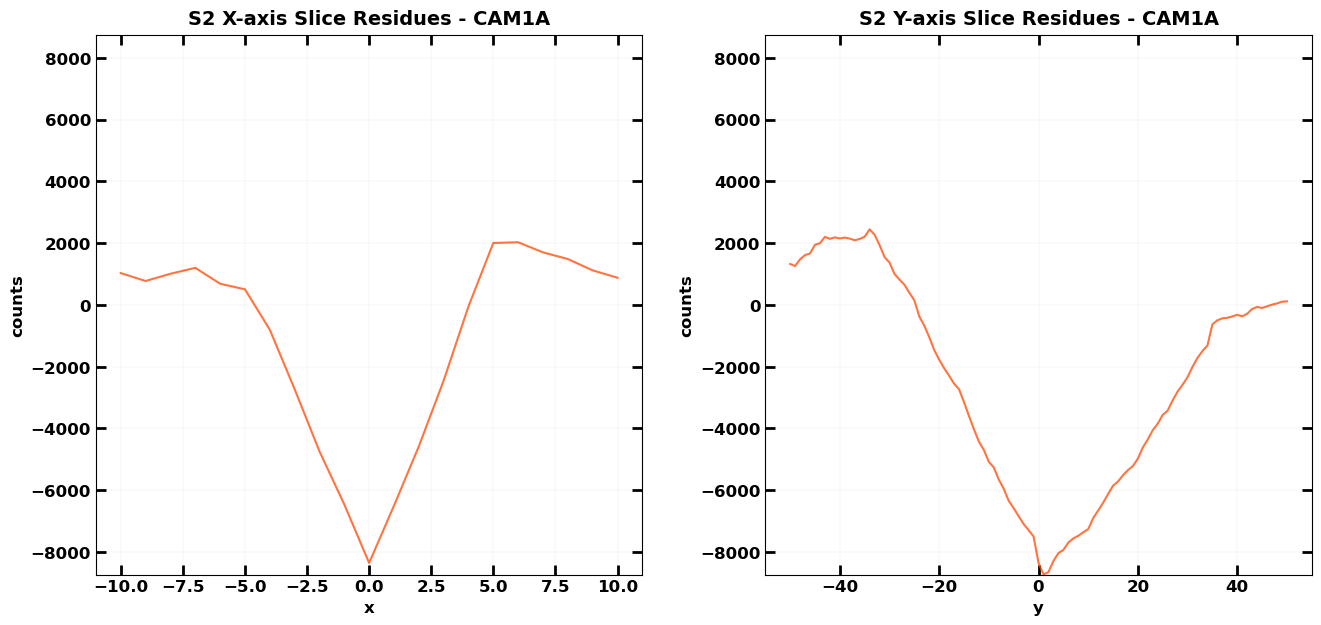

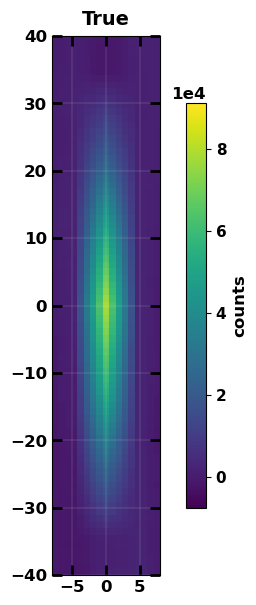

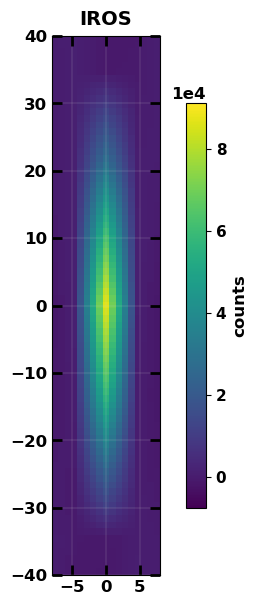

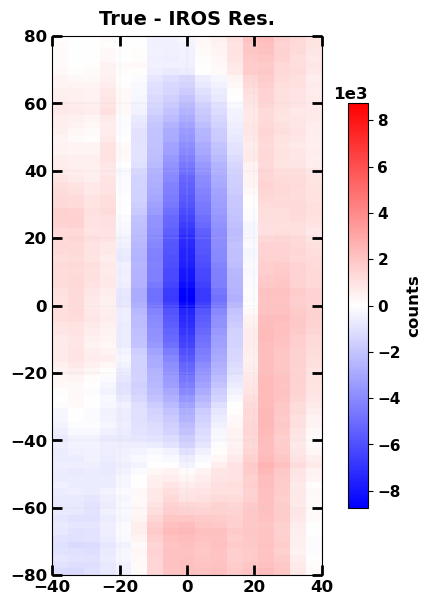

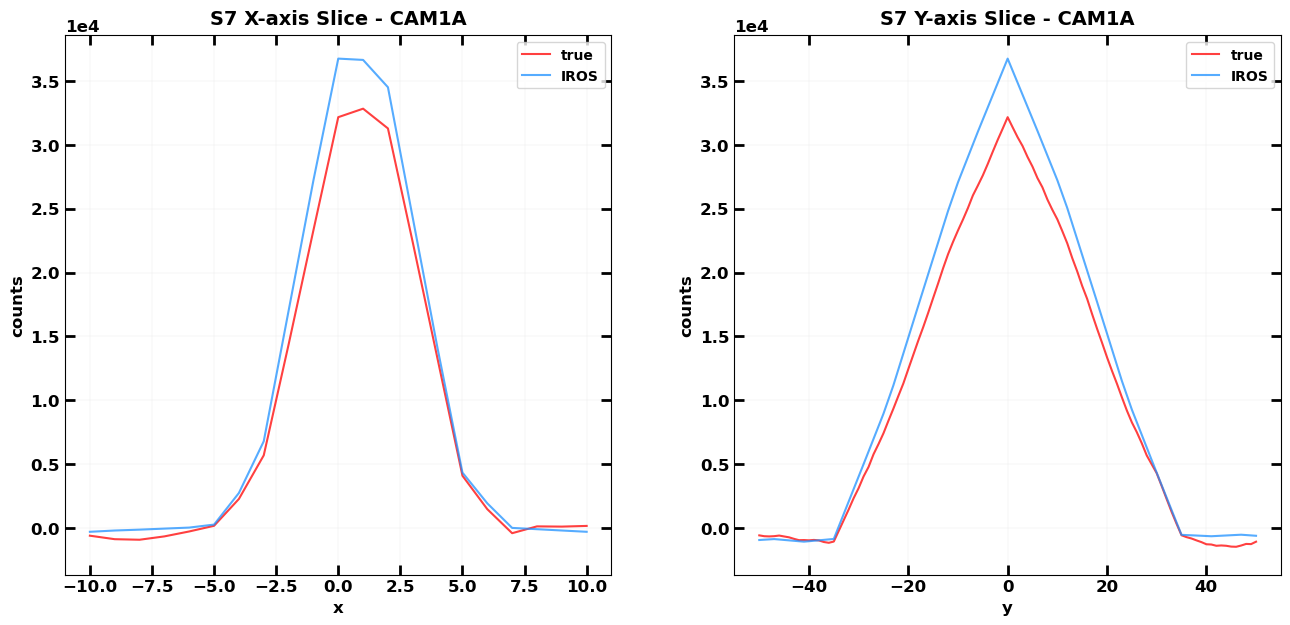

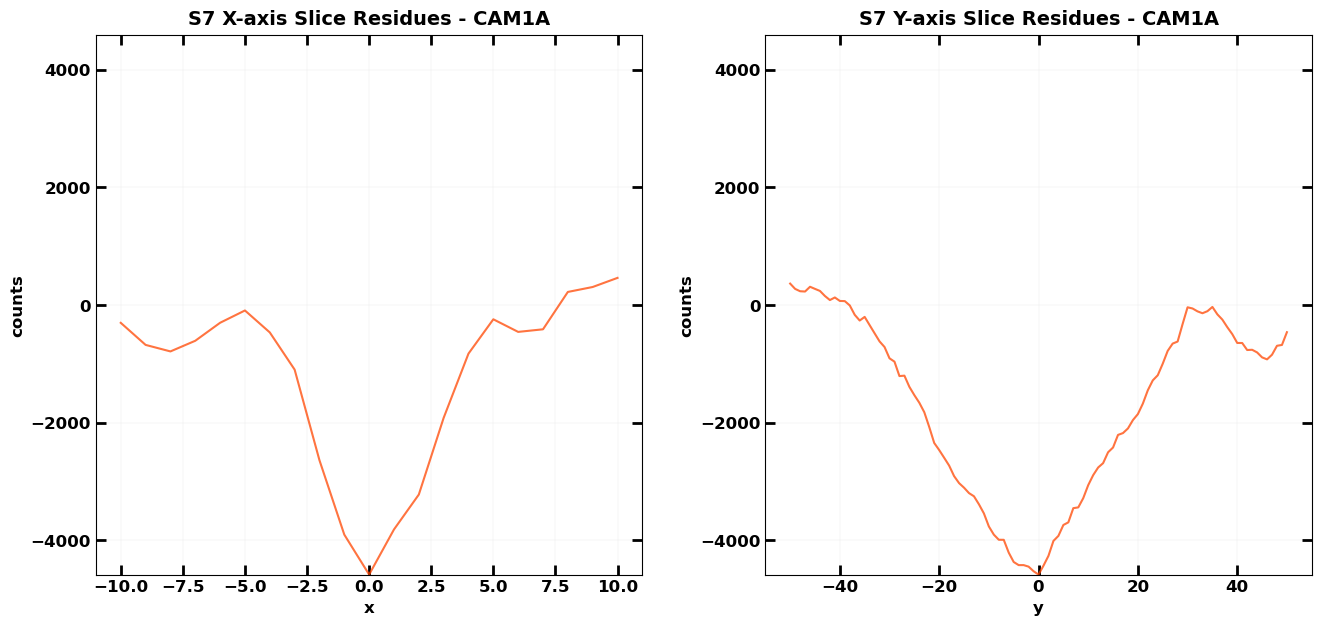

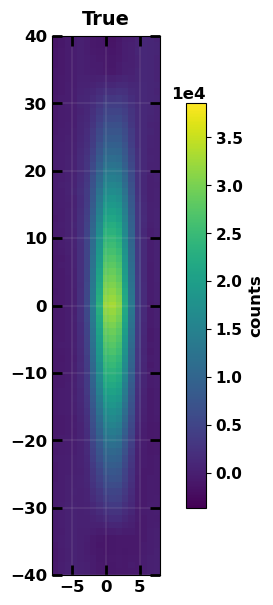

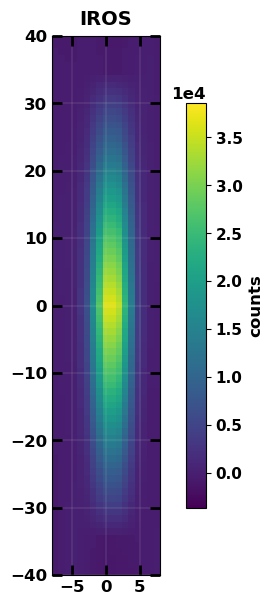

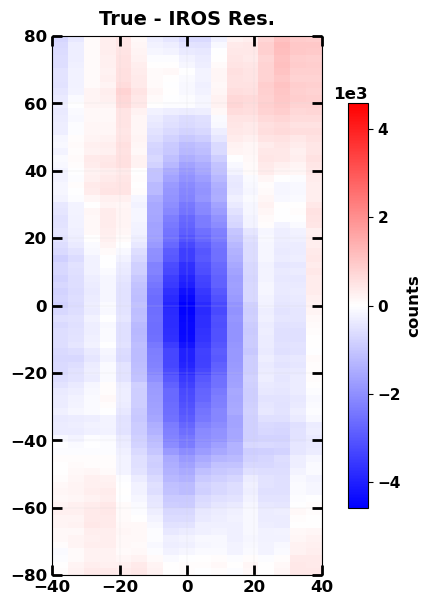

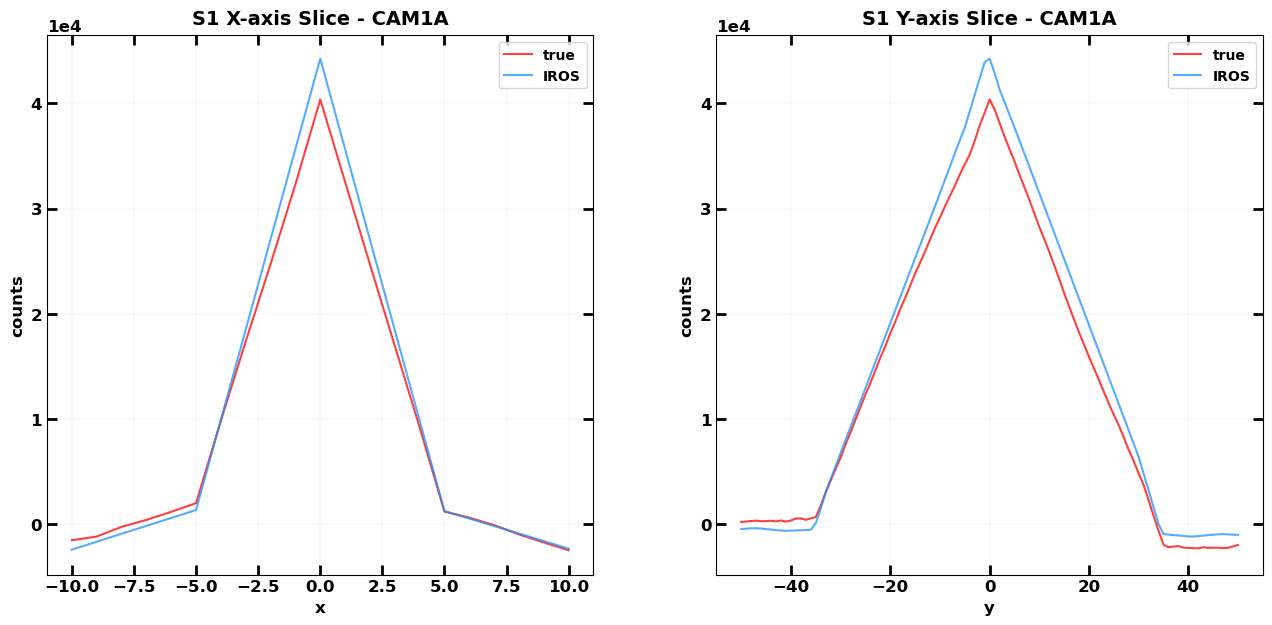

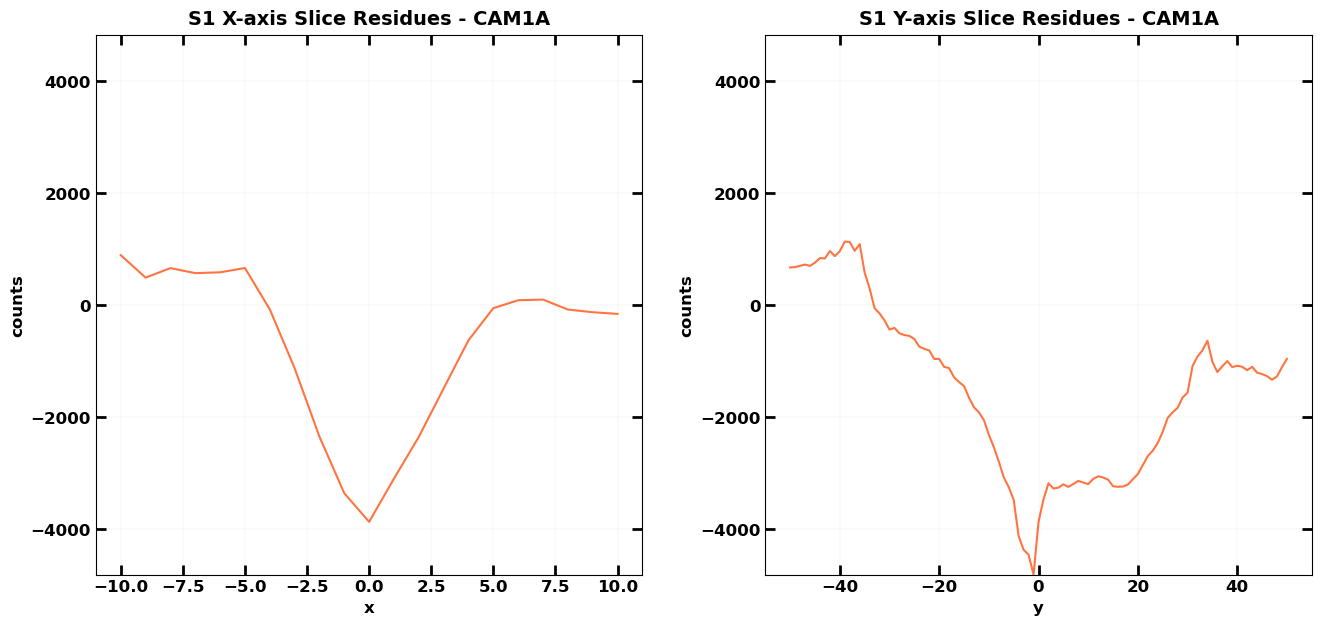

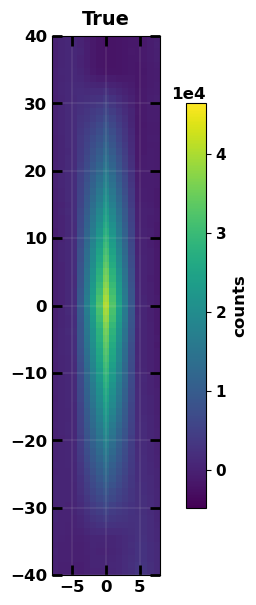

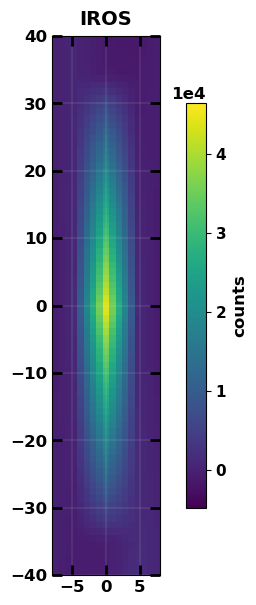

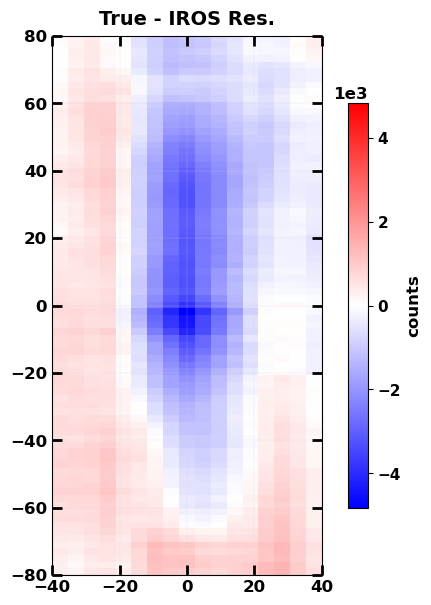

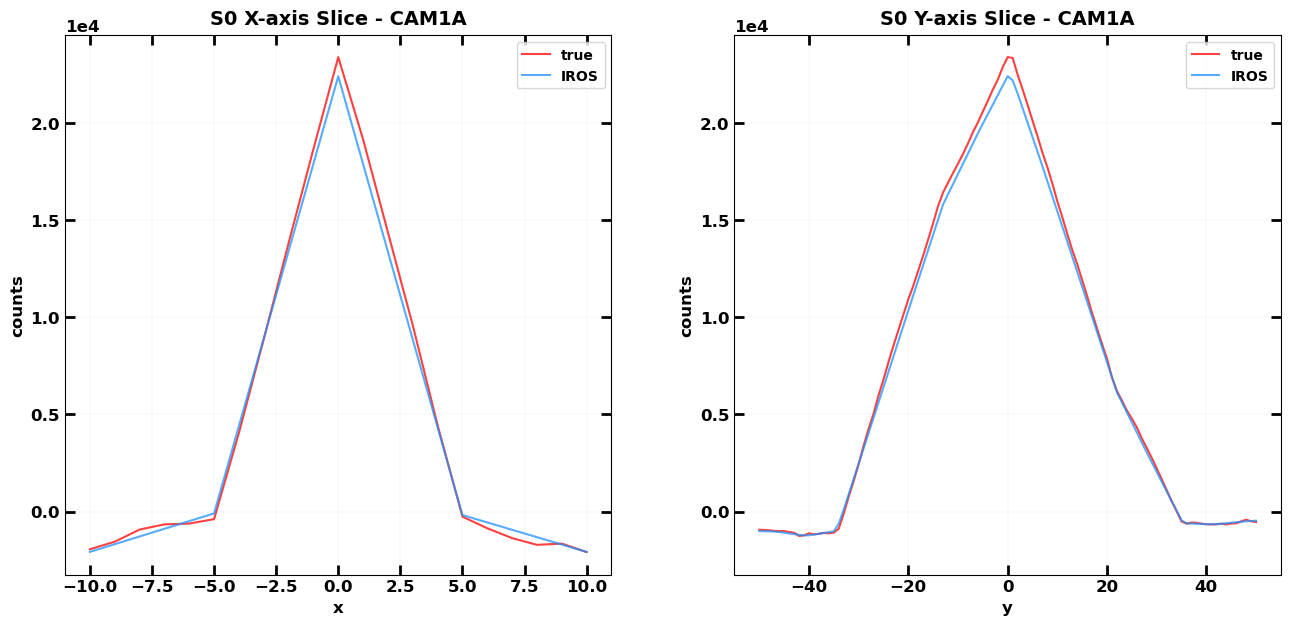

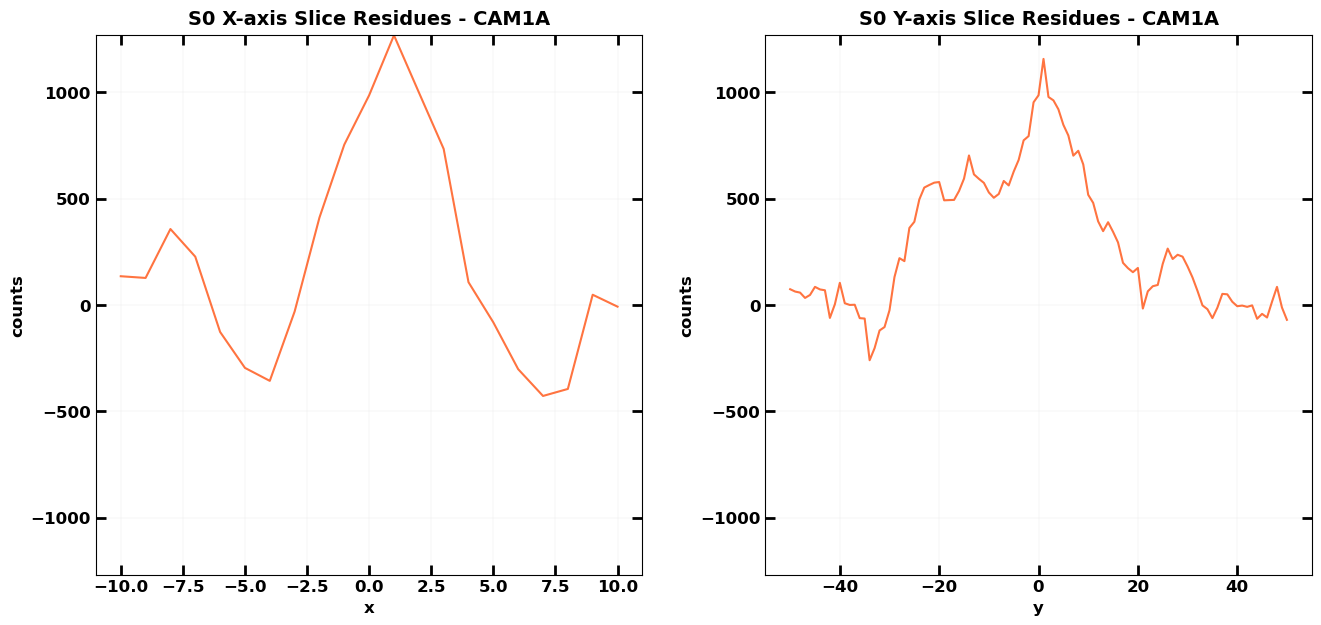

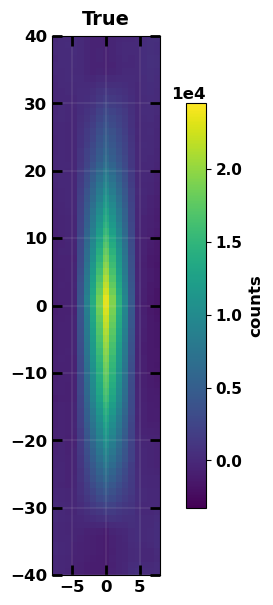

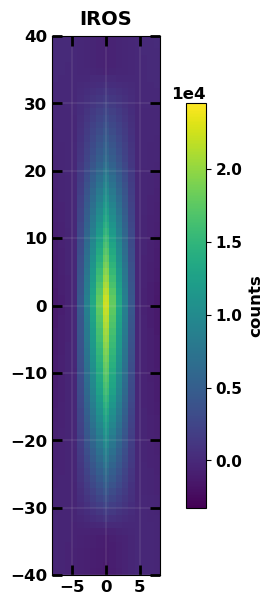

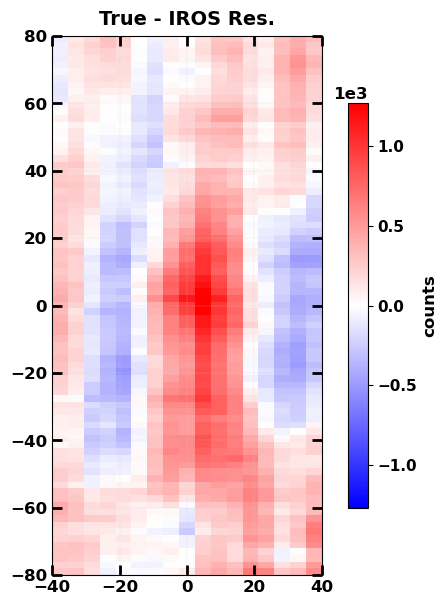

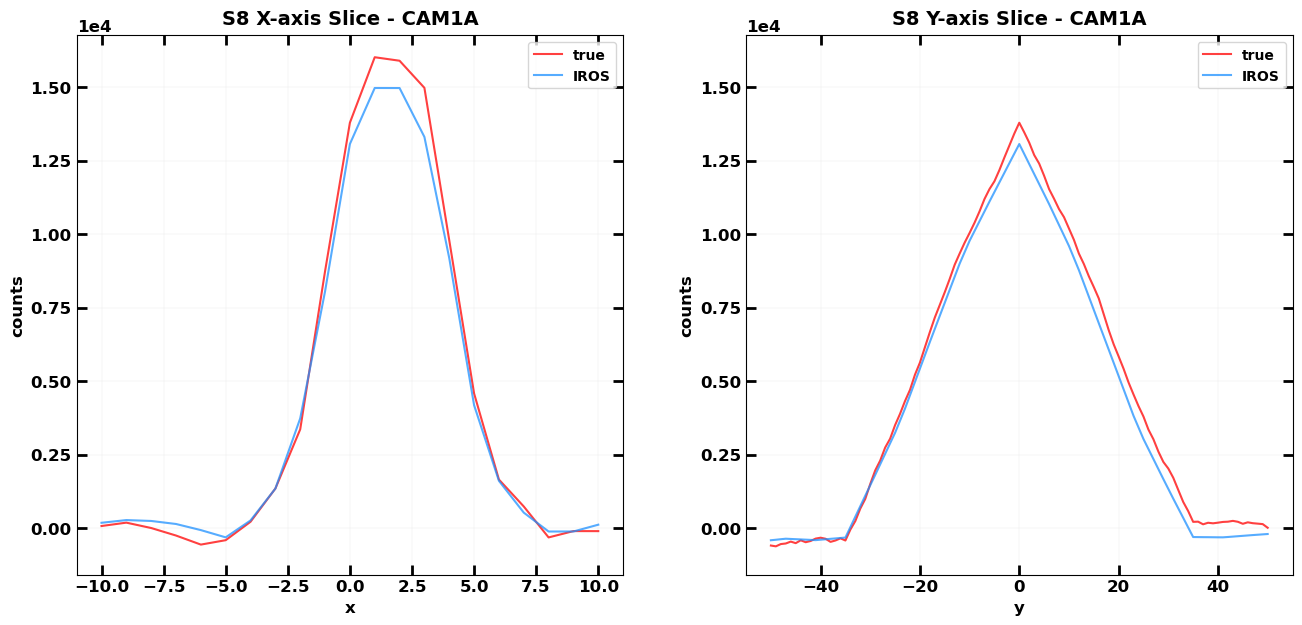

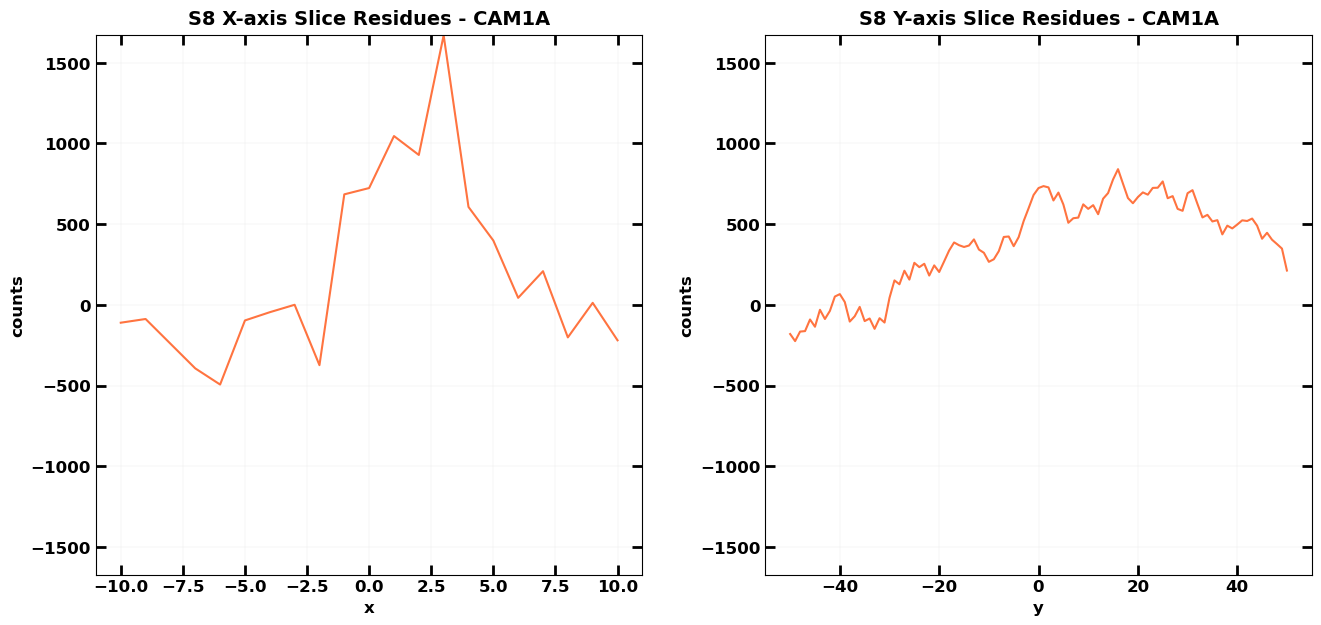

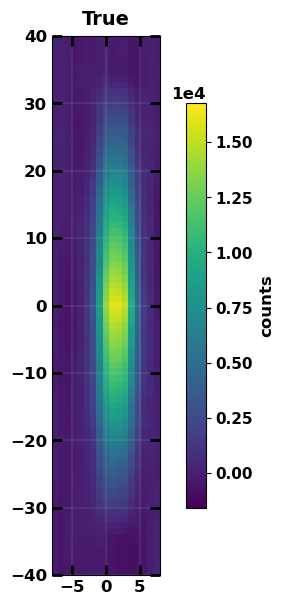

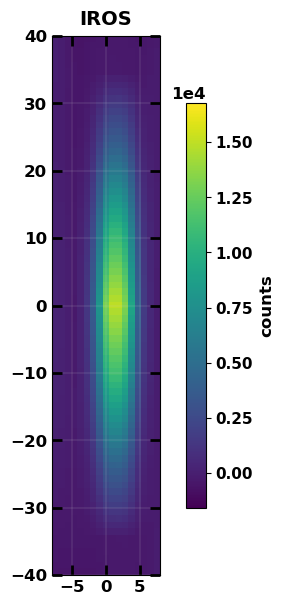

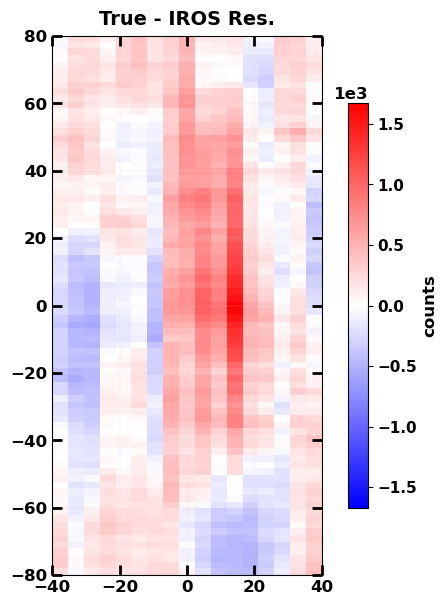

In [4]:
def plot_IROS_sources(
    data: dict,
    cameraID: str,
    true_sky: NDArray,
    crp: tuple[int, int],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> None:
    """
    
    """
    true_sky = true_sky.copy()
    UPX, UPY = camera.upscale_f

    for source, sx, sy, f, x, y in zip(
        data[cameraID]["catalog_name"]["data"],
        data[cameraID]["shift_x"]["data"],
        data[cameraID]["shift_y"]["data"],
        data[cameraID]["fluence"]["data"],
        data[cameraID]["x"]["data"],
        data[cameraID]["y"]["data"],
    ):
        # simulate source
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        _crp_true = true_sky[y - crp[0] : y + crp[0] + 1, x - crp[1] : x + crp[1] + 1]
        _crp_modeled = modeled[y - crp[0] : y + crp[0] + 1, x - crp[1] : x + crp[1] + 1]
        _l = max(
            np.abs(_crp_true - _crp_modeled)[crp[0], :].max(),
            np.abs(_crp_true - _crp_modeled)[:, crp[1]].max(),
        )
        COUNTS_LIMS = (
            min(_crp_true.min(), _crp_modeled.min()) - f // 20,
            max(_crp_true.max(), _crp_modeled.max()) + f // 20,
        )
        RES_LIMS = (-_l, _l)
        POS = (y, x)

        # plot true sky and source model
        enhance_slices(
            sky=[true_sky, modeled],
            label=[("true", "IROS")] * 2,
            pos=POS,
            crp=crp,
            source=source,
            cameraID=cam_a,
            offsety_first=[COUNTS_LIMS] * 2,
            offsety_second=[RES_LIMS] * 2,
            #save_to_first=save_path + "../models.png",
            #save_to_second=save_path + "../res.png",
        )

        # plot heatmaps
        CUT = (40, 8)
        EXTENT = (-CUT[1], CUT[1], -CUT[0], CUT[0])
        DPI = 100
        SCINOT = True

        true_cropped = iros.crop(
            image=true_sky,
            pos=POS,
            cropping=CUT,
        )
        modeled_cropped = iros.crop(
            image=modeled,
            pos=POS,
            cropping=CUT,
        )

        image_plot(
            arr=true_cropped,
            title="True",
            #xlabel="x",
            #ylabel="y",
            cbarlabel="counts",
            cmap="viridis",
            vmin=COUNTS_LIMS[0],
            vmax=COUNTS_LIMS[1],
            extent=EXTENT,
            dpi=DPI,
            cbarscinot=SCINOT,
        )
        image_plot(
            arr=modeled_cropped,
            title="IROS",
            #xlabel="x",
            #ylabel="y",
            cbarlabel="counts",
            cmap="viridis",
            vmin=COUNTS_LIMS[0],
            vmax=COUNTS_LIMS[1],
            extent=EXTENT,
            dpi=DPI,
            cbarscinot=SCINOT,
        )

        f_upy, f_upx = 2, 5
        image_plot(
            arr=upscale(true_cropped - modeled_cropped, f_upy, f_upx) * np.prod((f_upy, f_upx)),
            title="True - IROS Res.",
            #xlabel="x",
            #ylabel="y",
            cbarlabel="counts",
            cmap="bwr",
            vmin=RES_LIMS[0],
            vmax=RES_LIMS[1],
            extent=(-CUT[1] * f_upx, CUT[1] * f_upx, -CUT[0] * f_upy, CUT[0] * f_upy),
            dpi=DPI,
            cbarscinot=SCINOT,
        )

        # remove source from true
        true_sky -= modeled


plot_IROS_sources(
    data=database,
    cameraID=cam_a,
    true_sky=simul_sky_camA,
    crp=(50, 10),
    camera=wfm,
    vignetting=True,
    psfy=False,
)

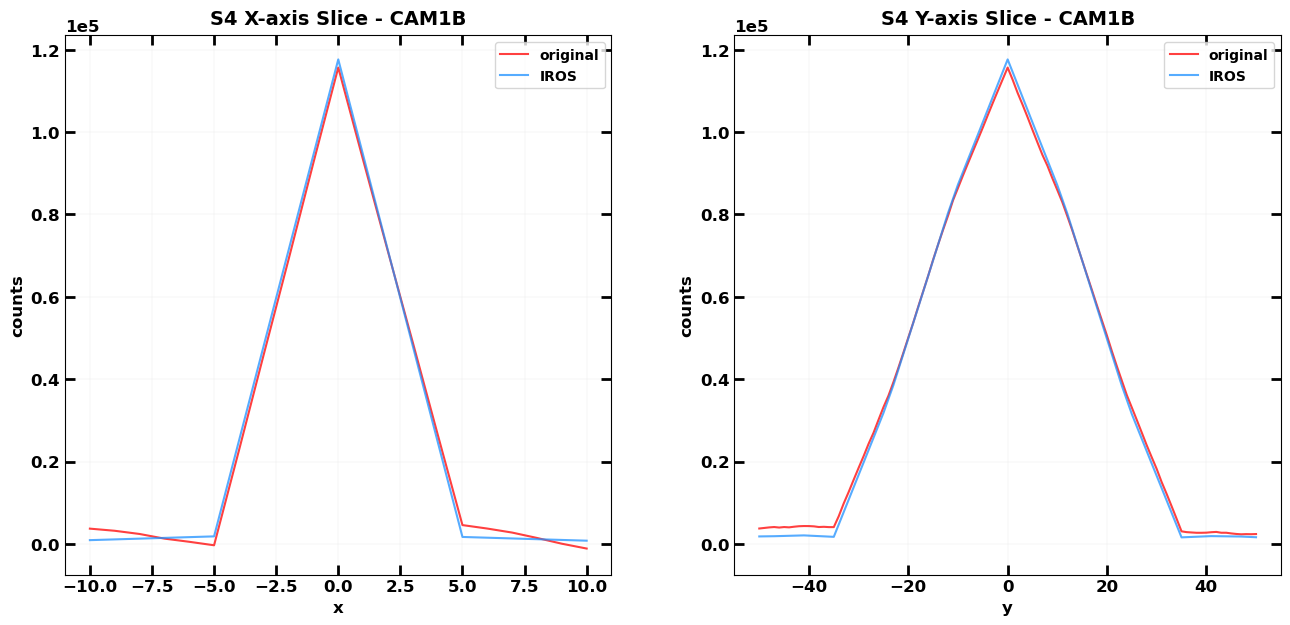

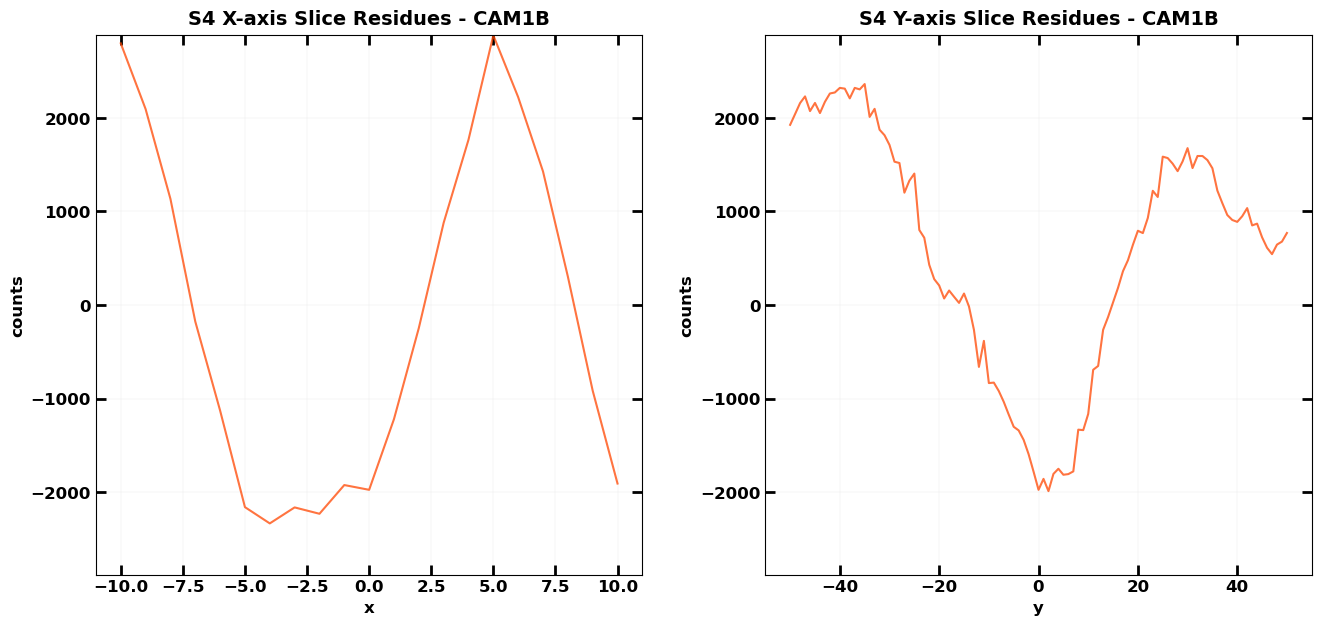

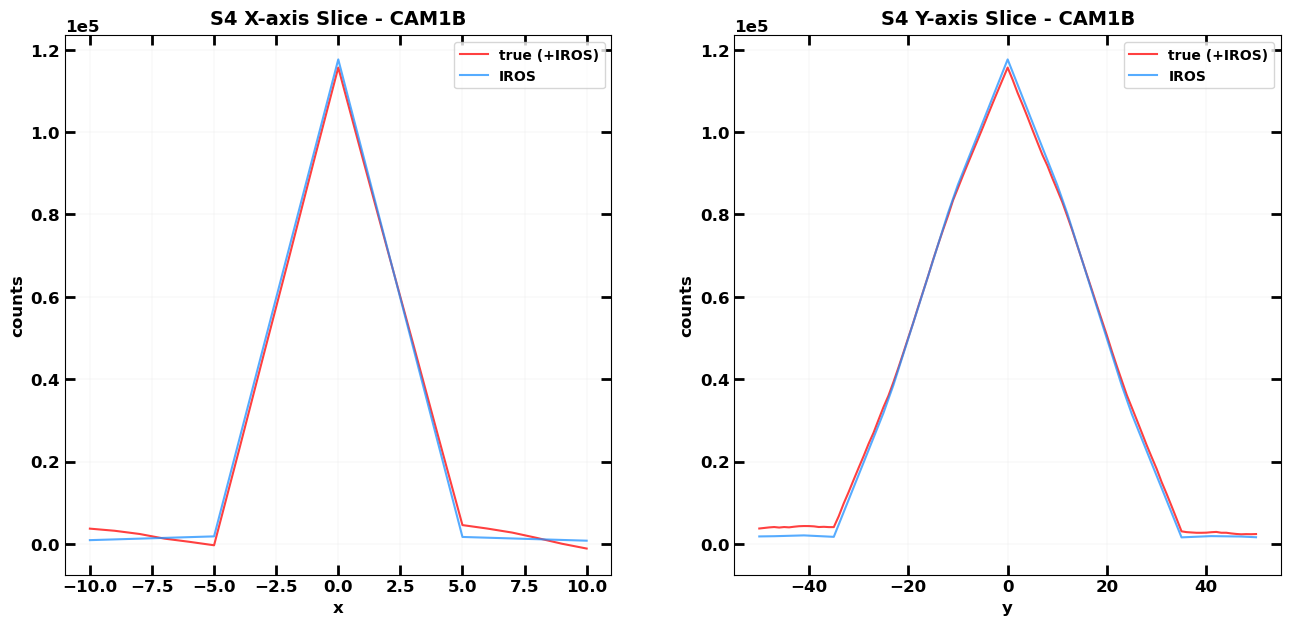

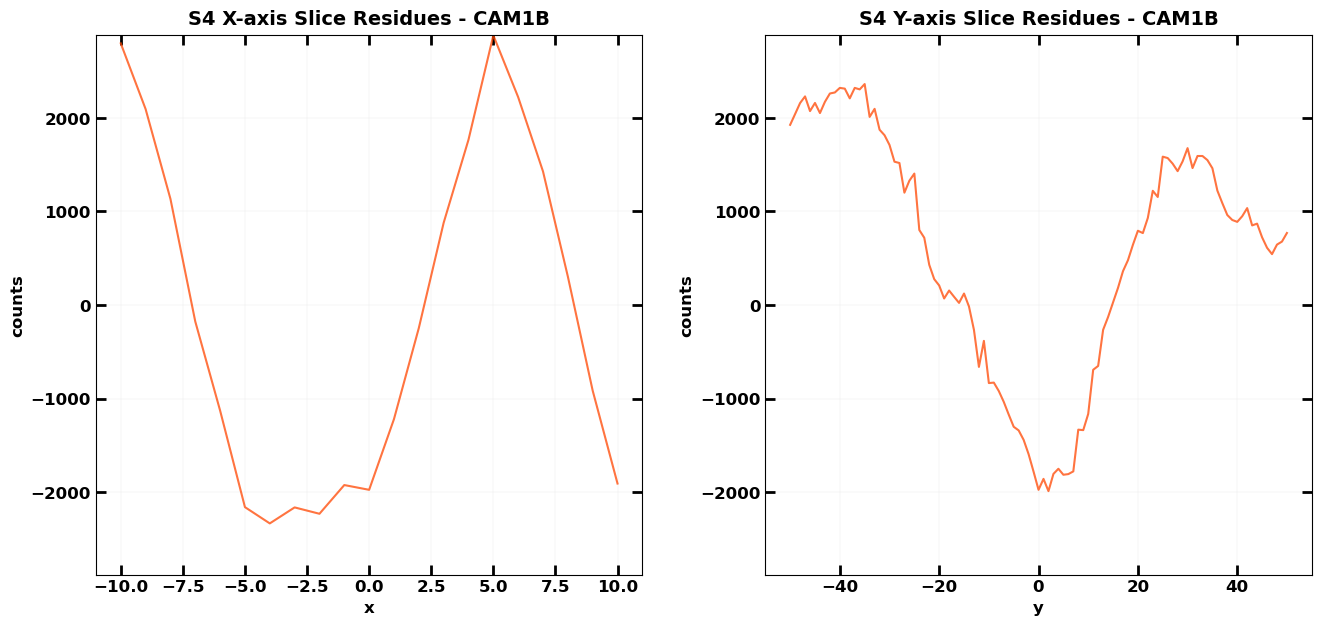

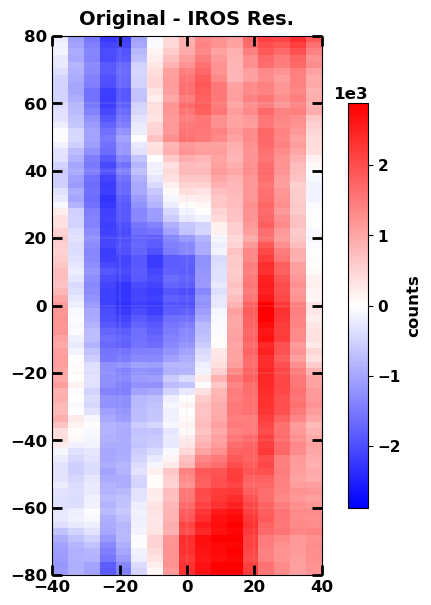

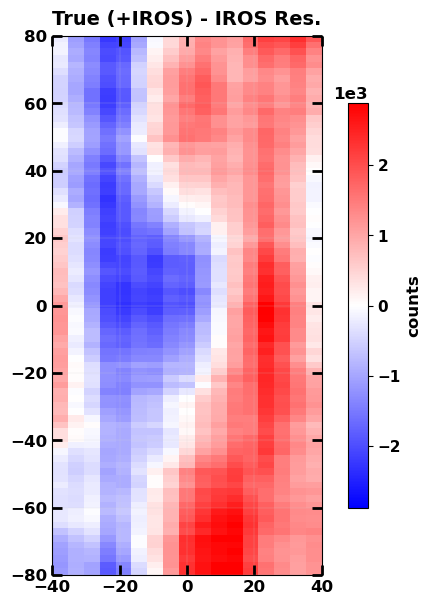

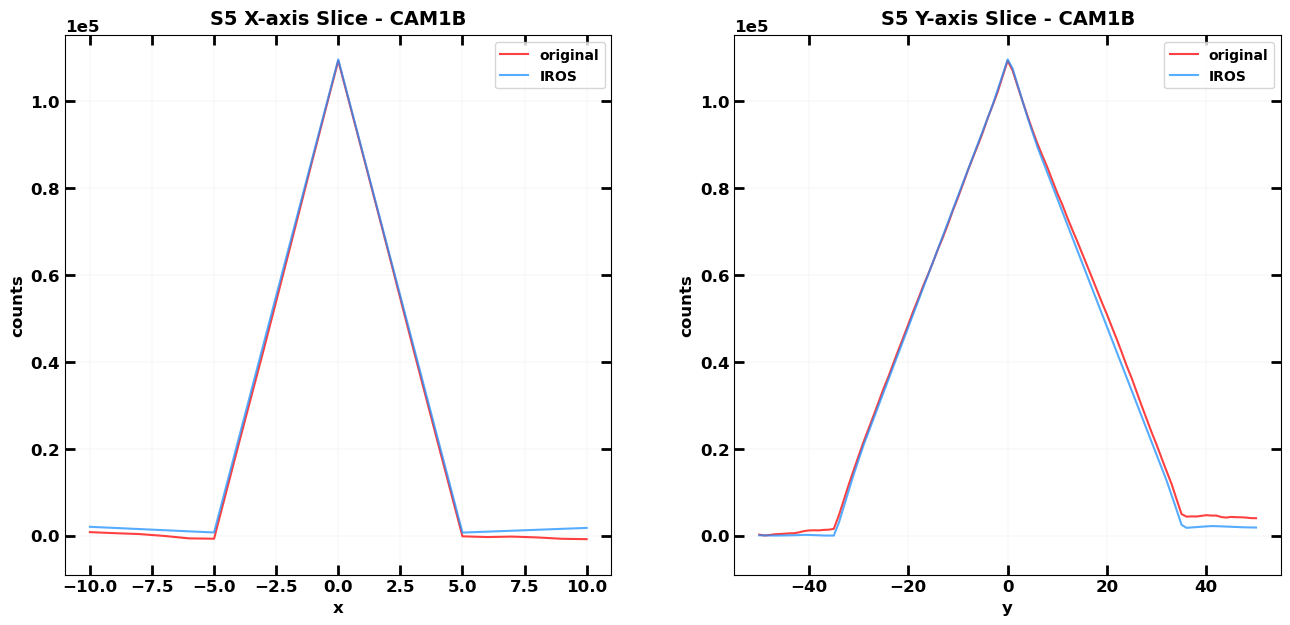

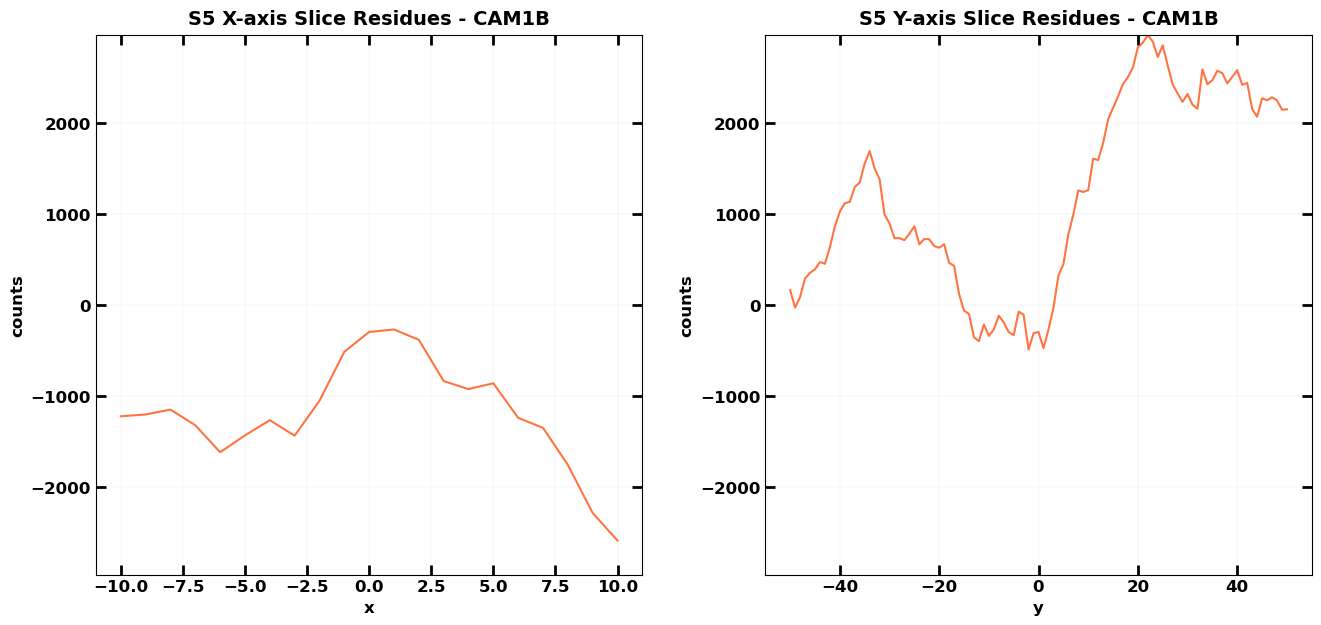

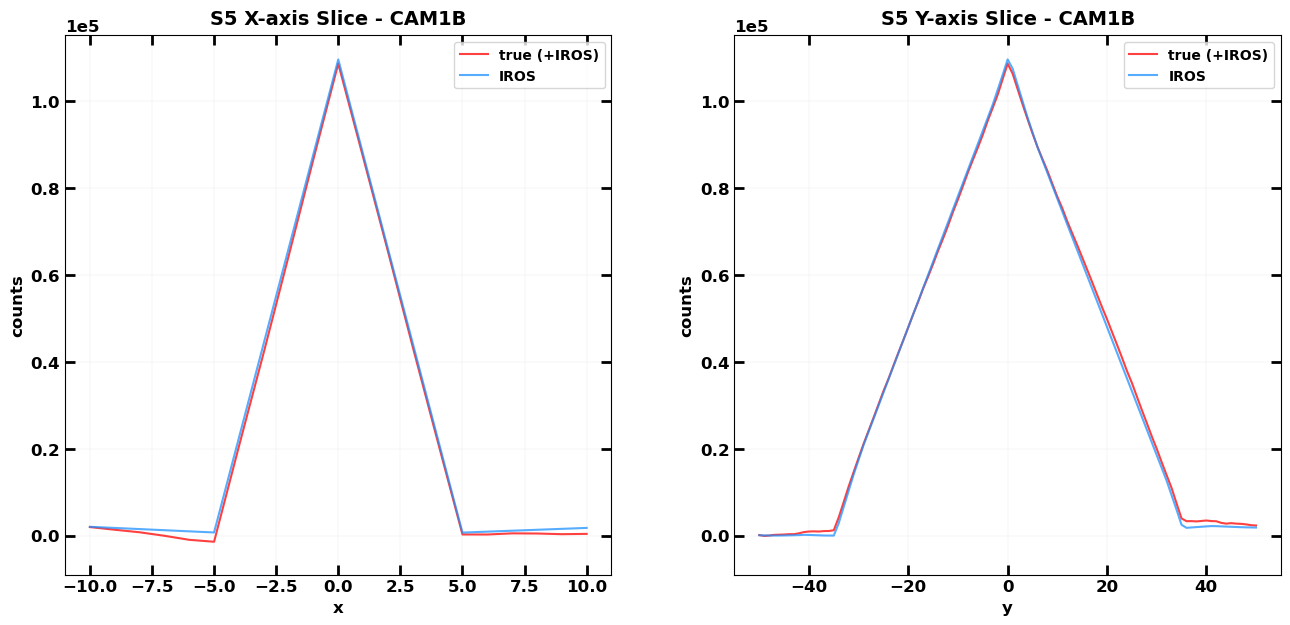

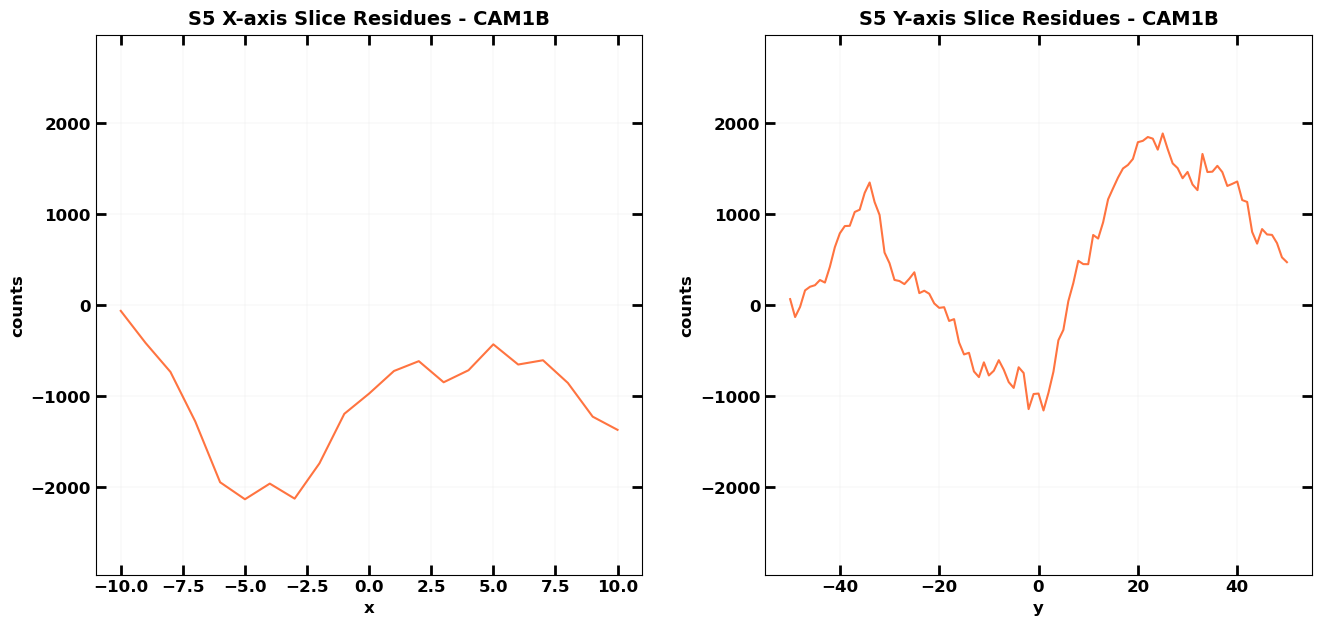

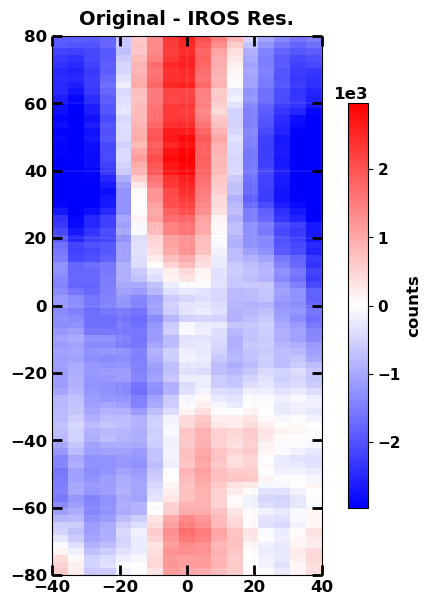

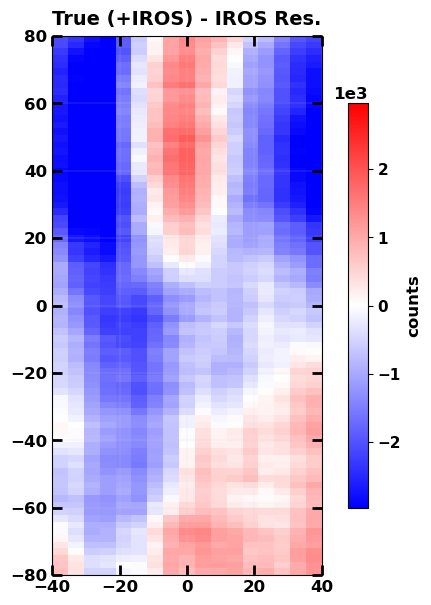

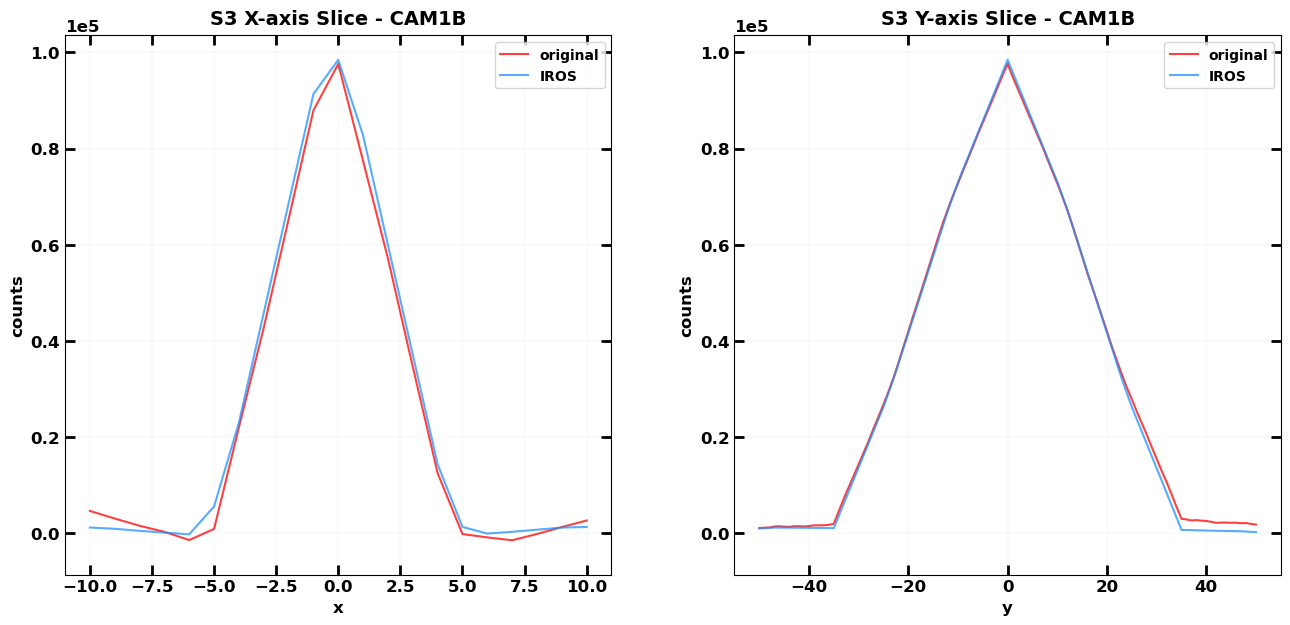

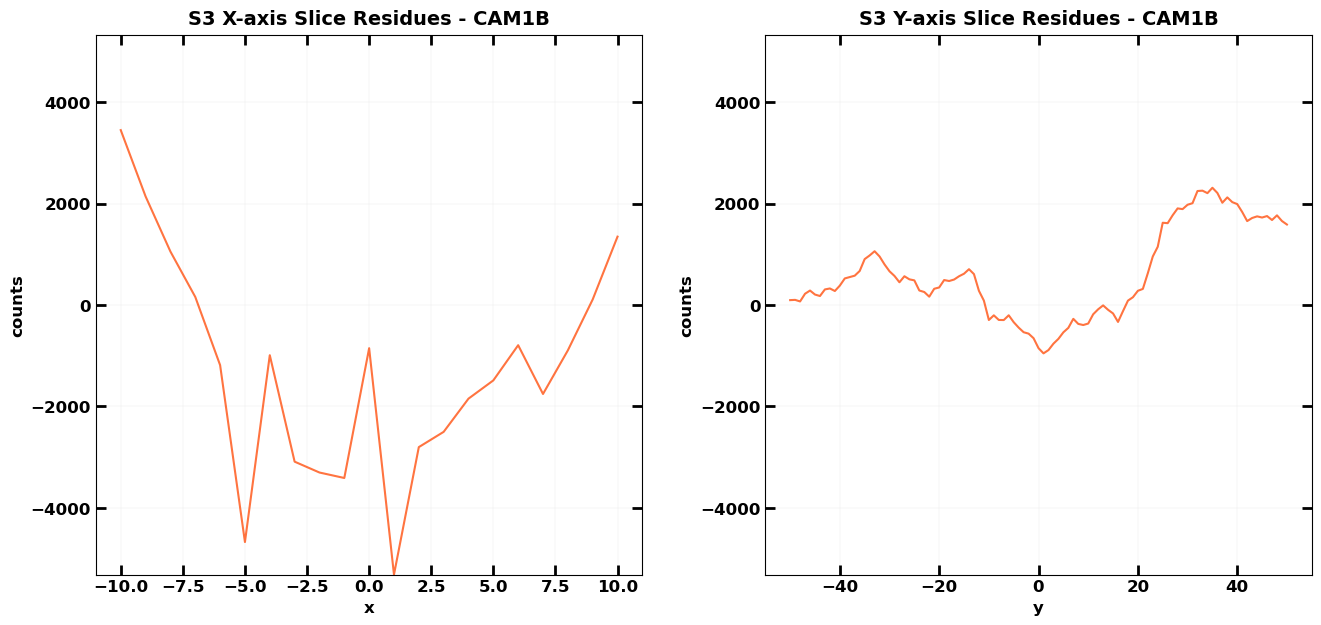

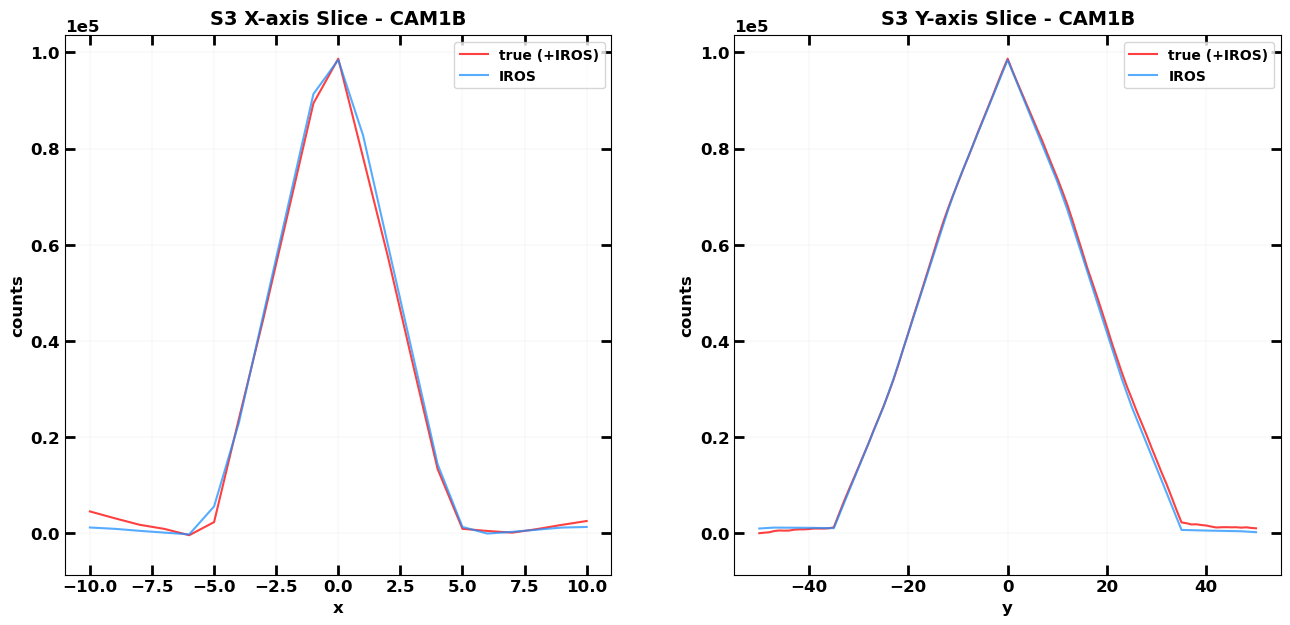

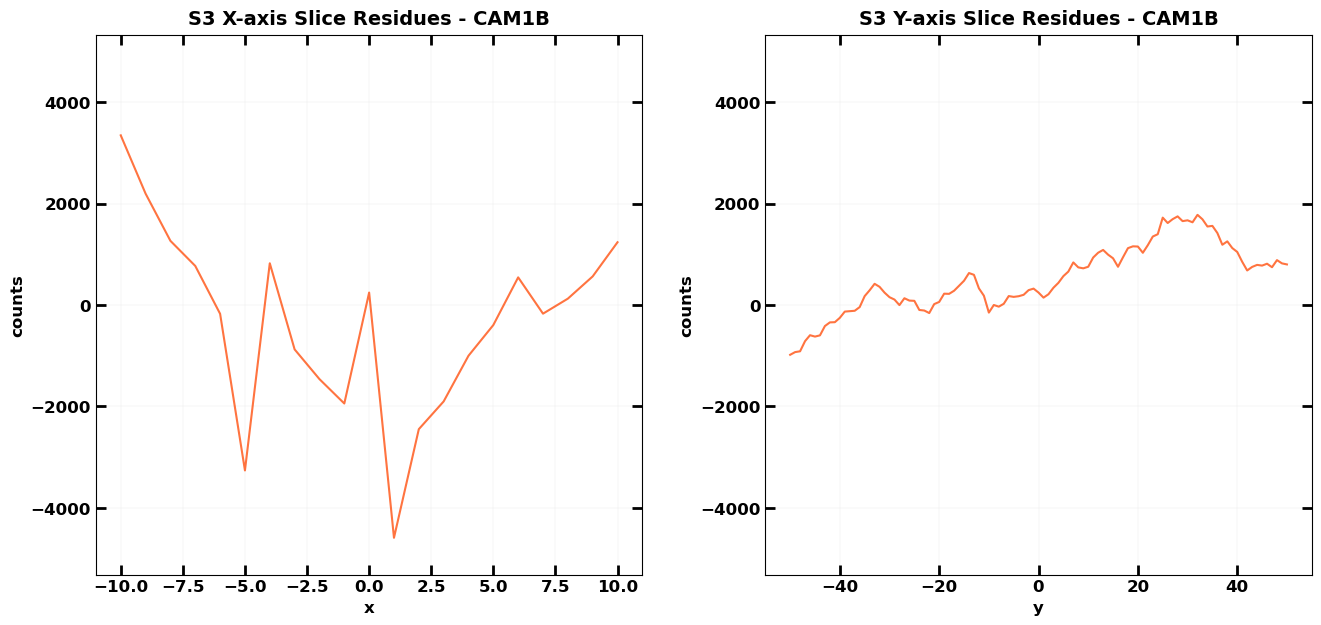

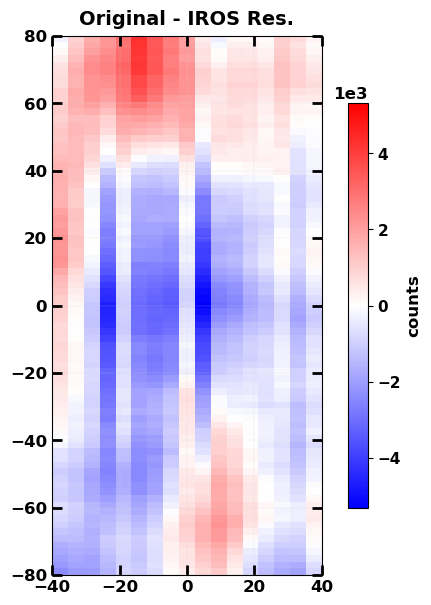

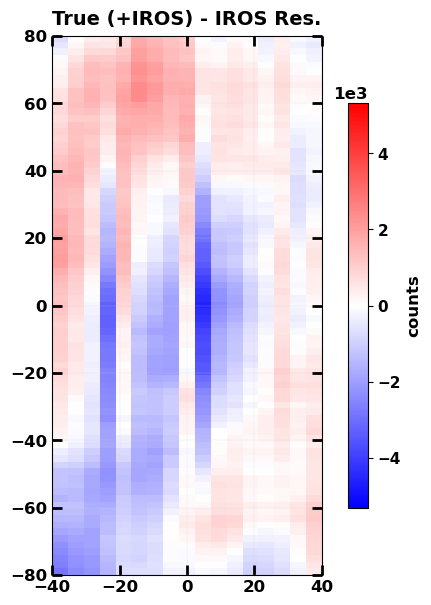

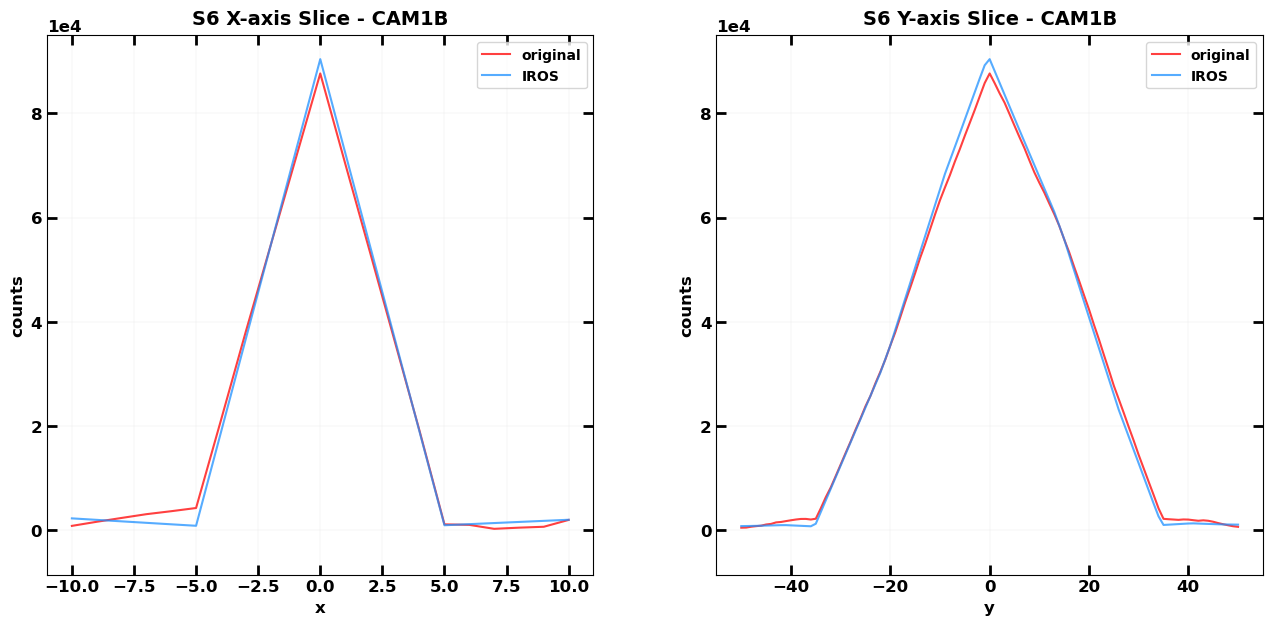

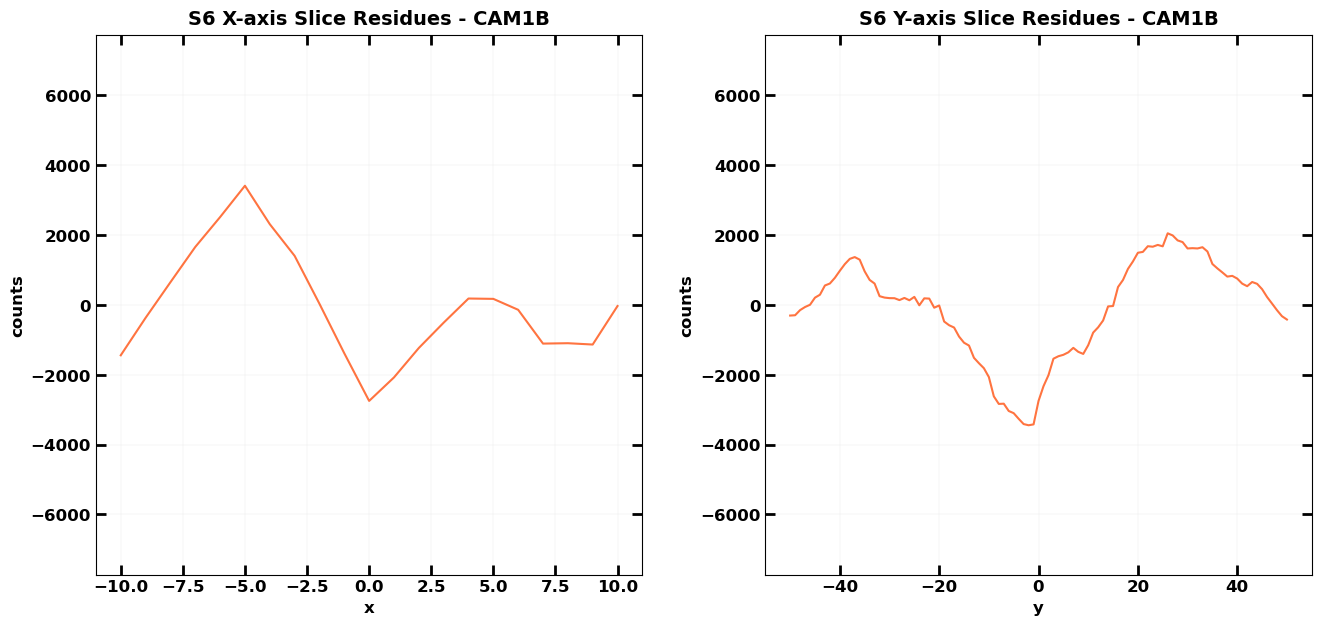

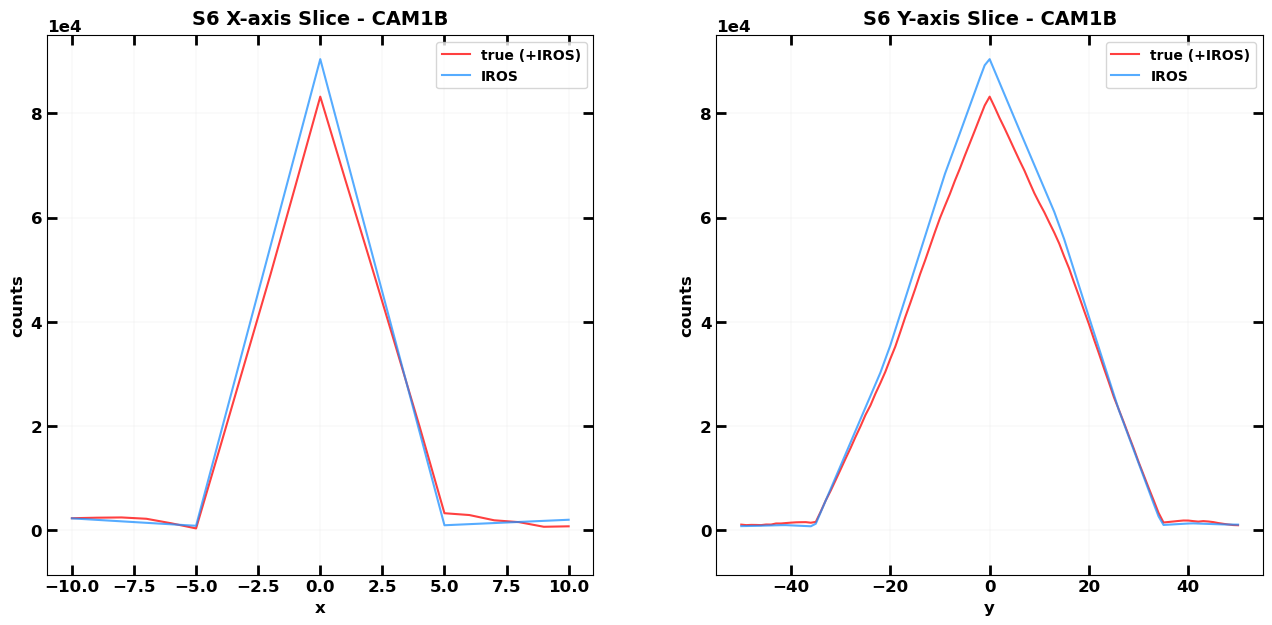

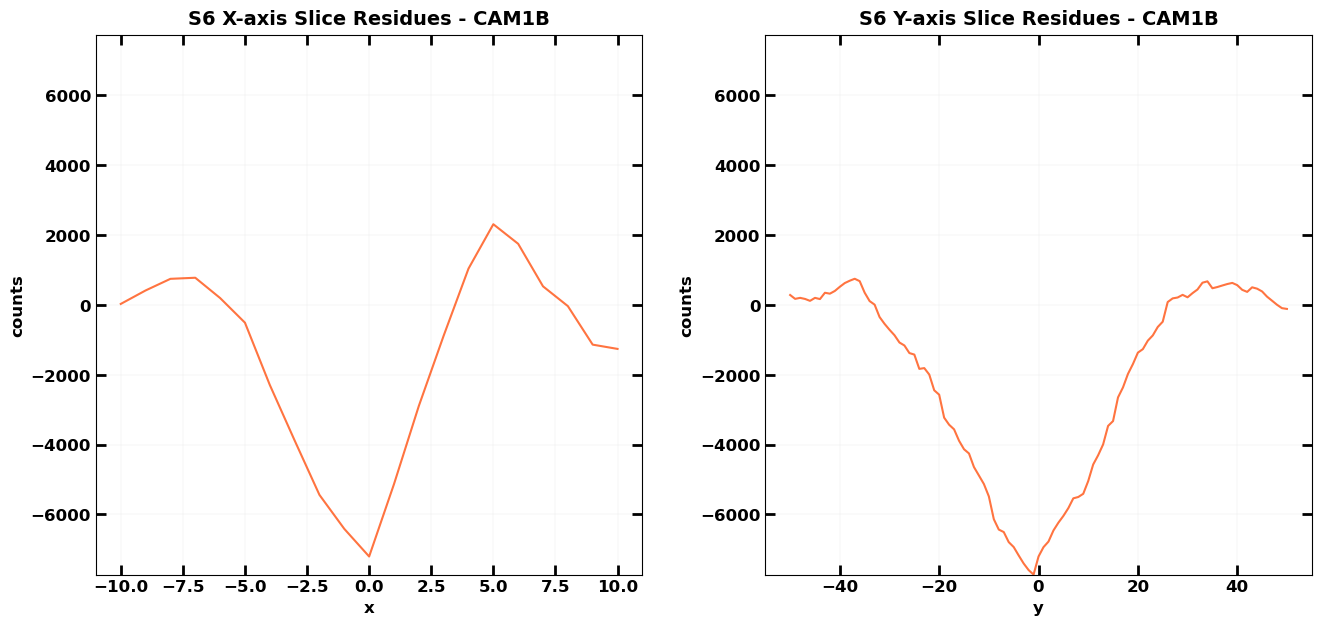

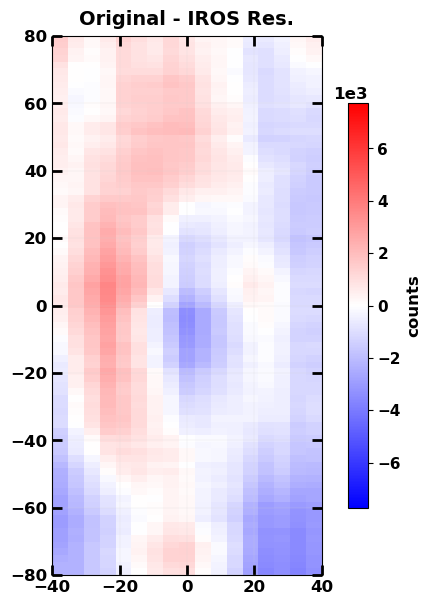

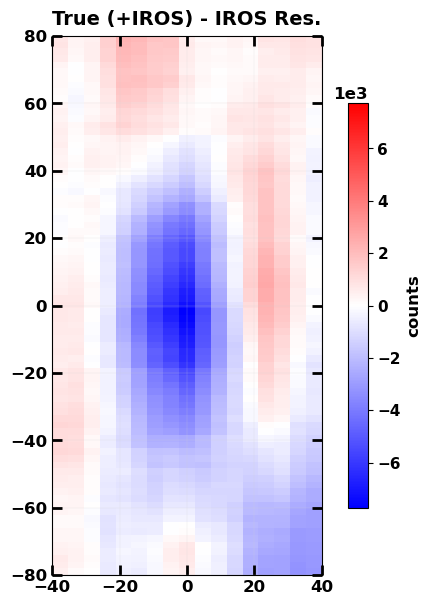

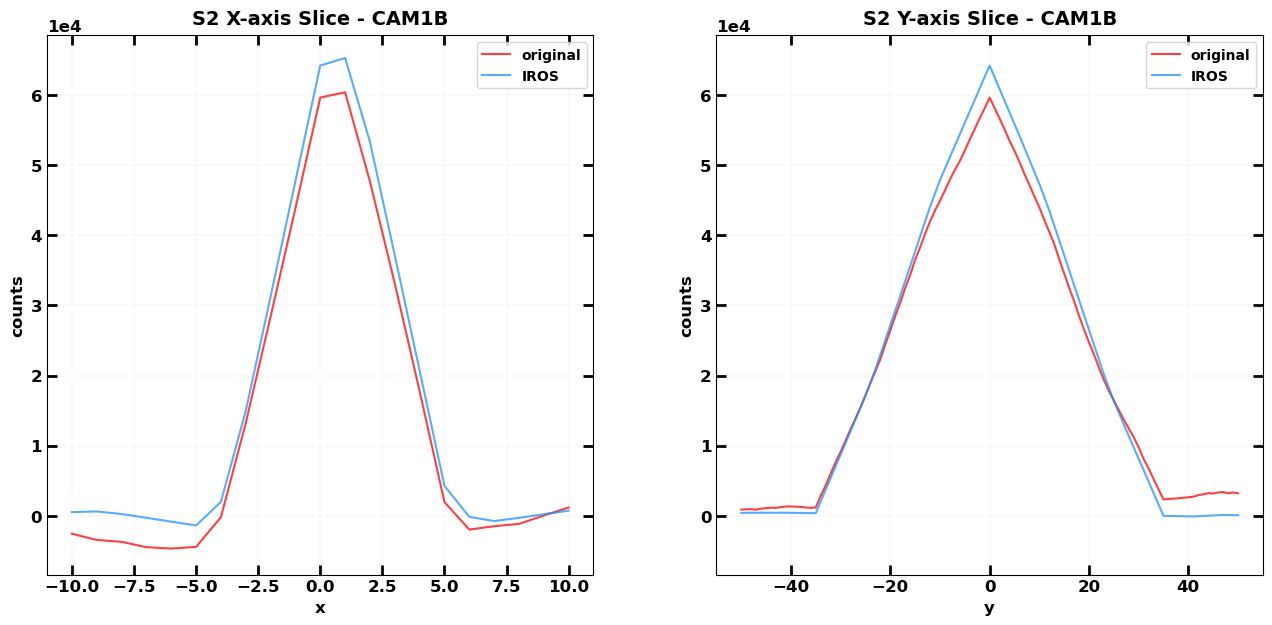

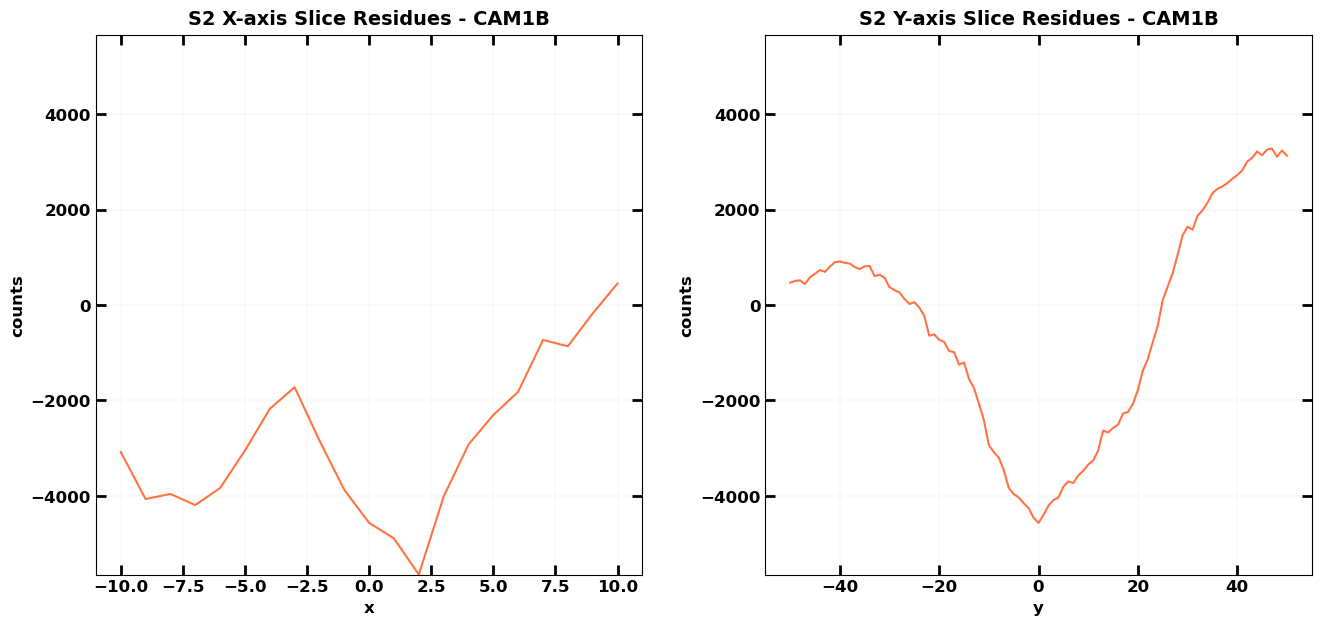

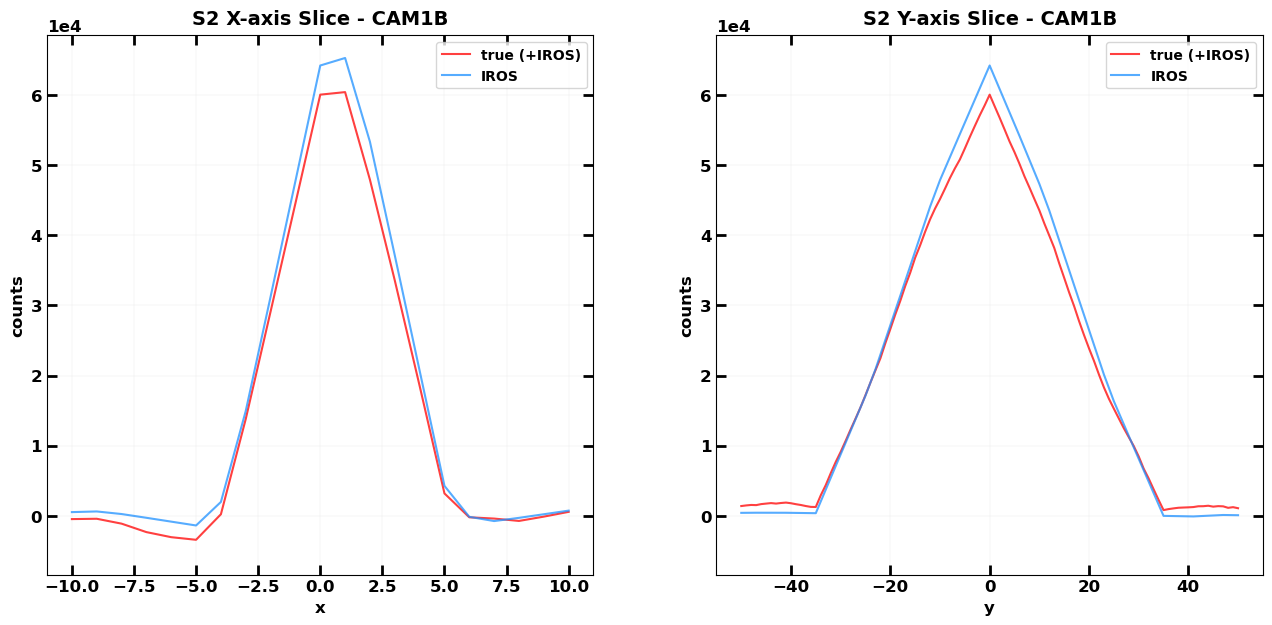

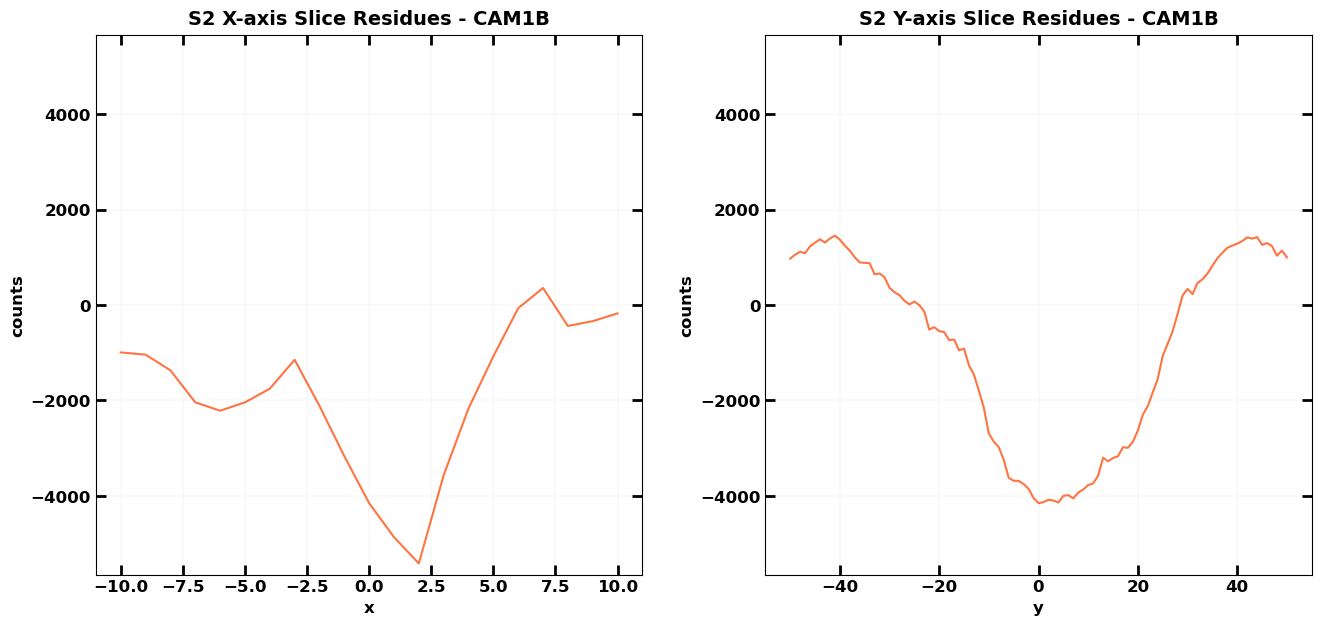

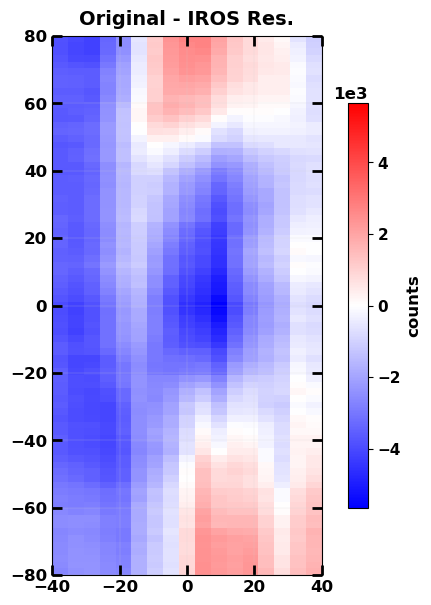

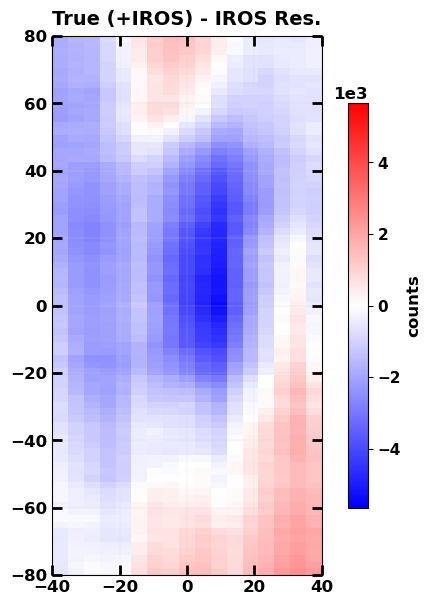

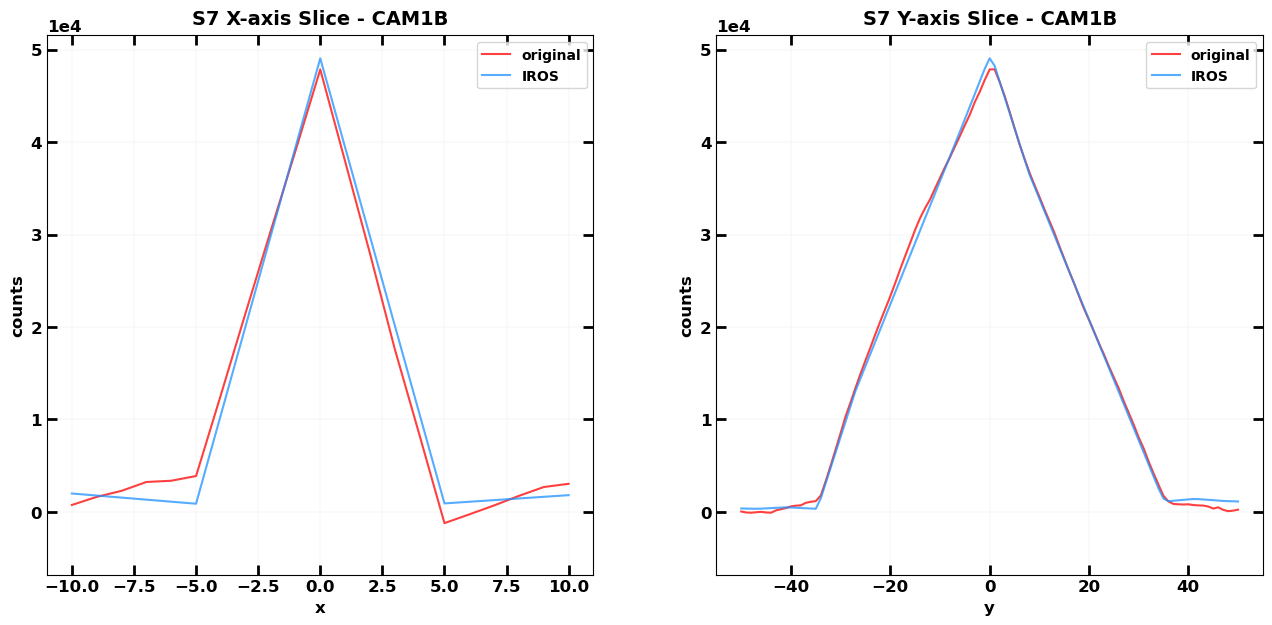

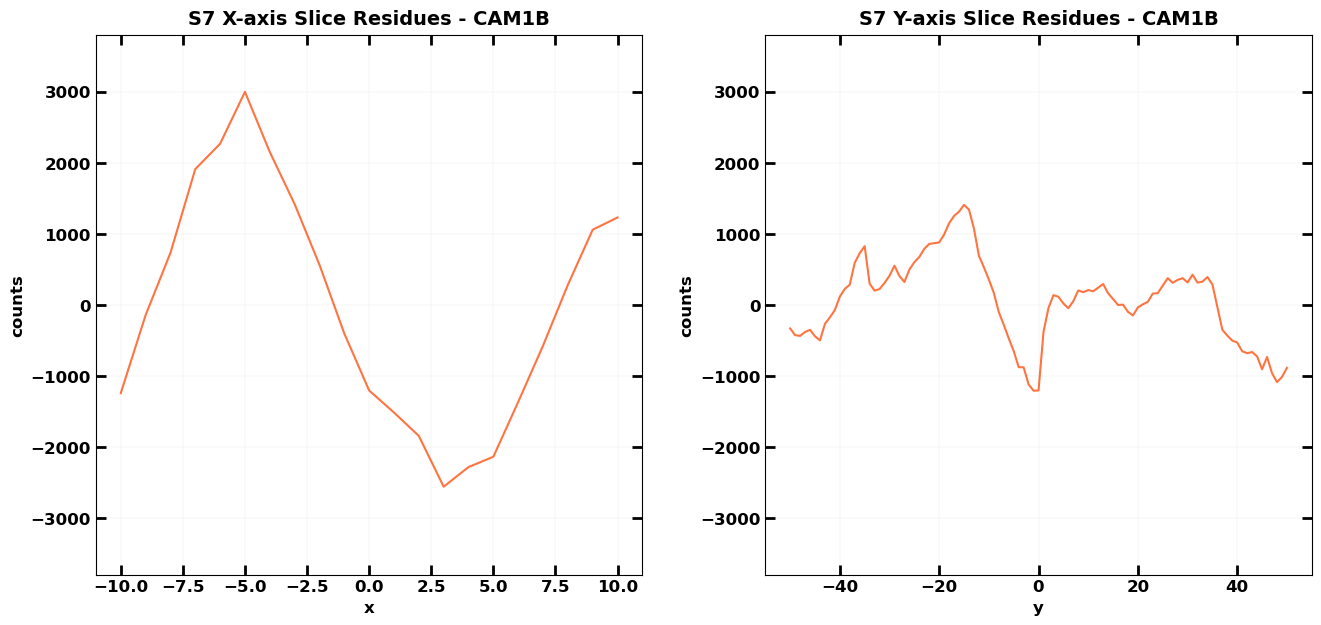

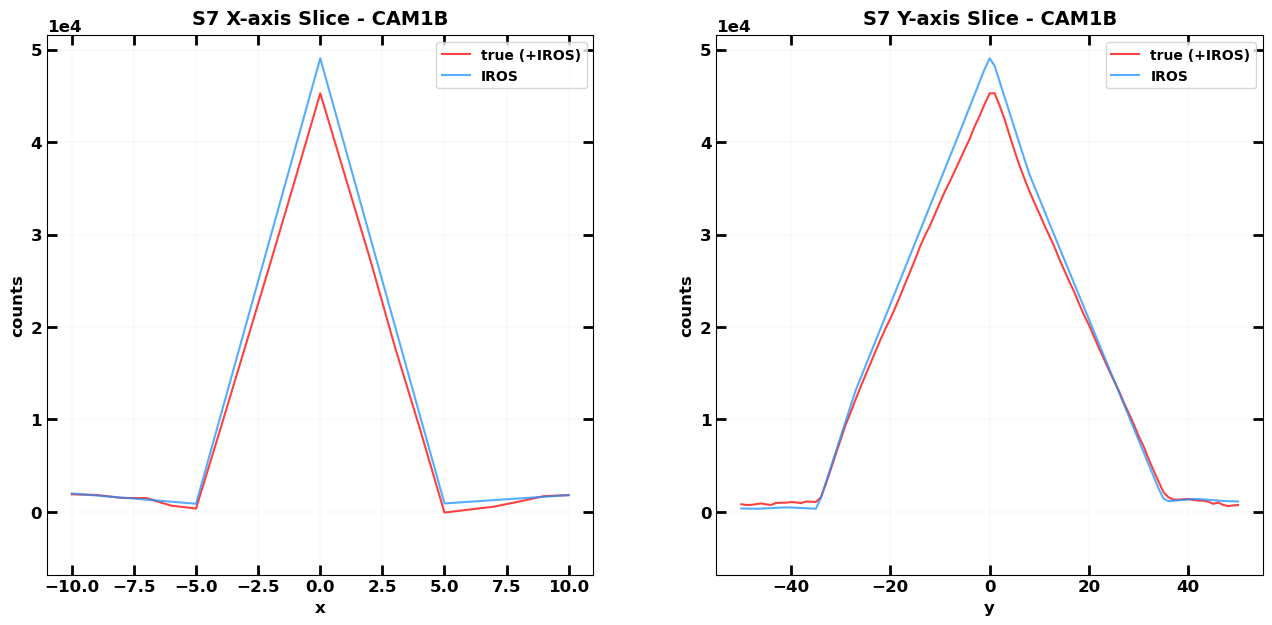

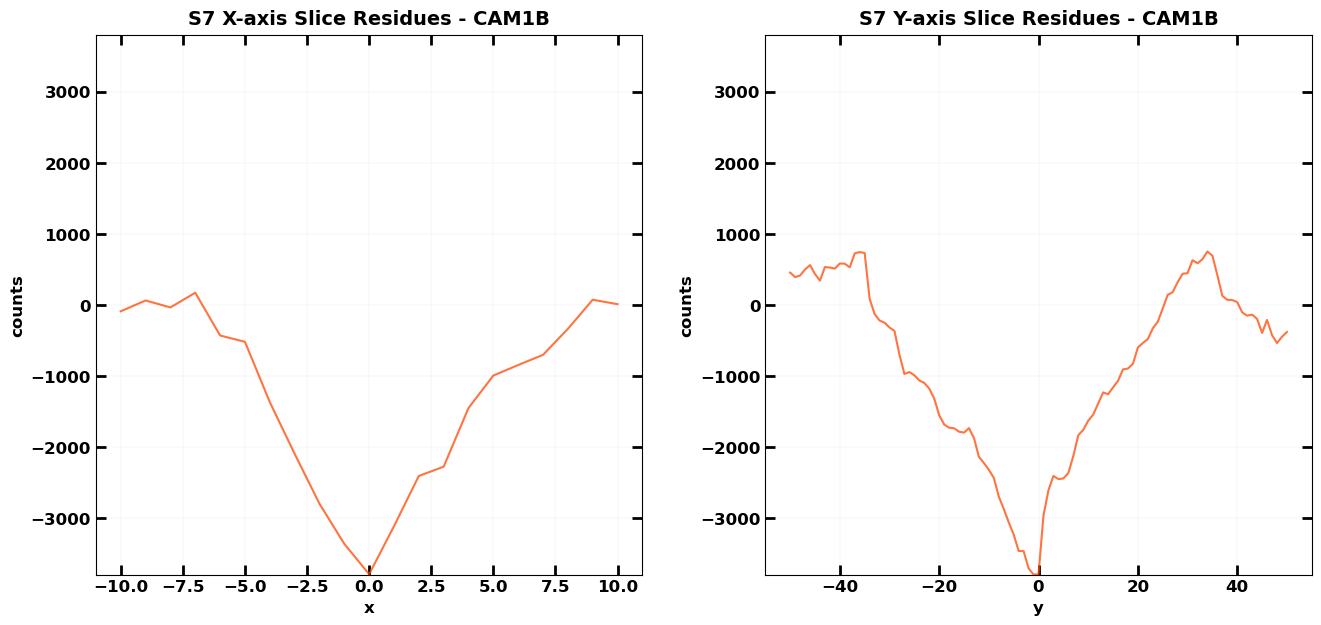

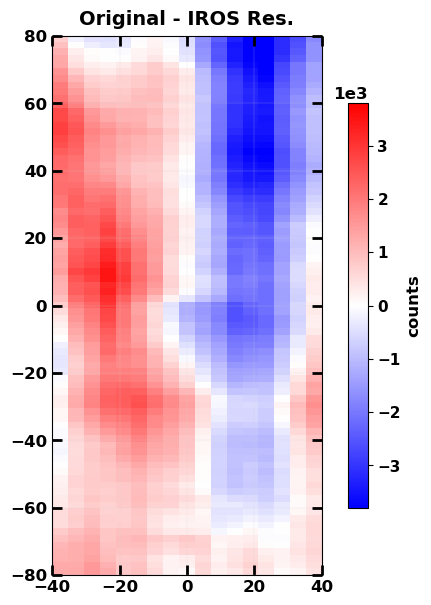

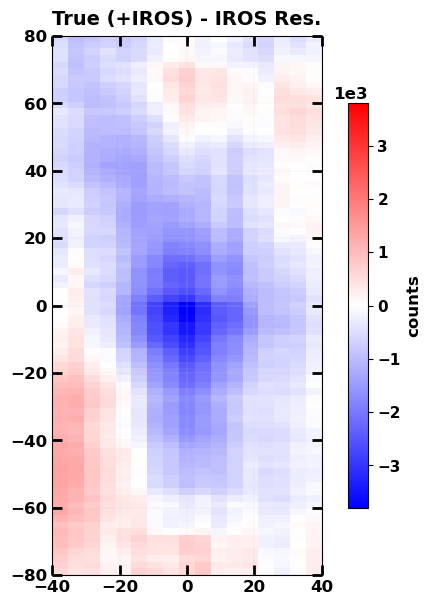

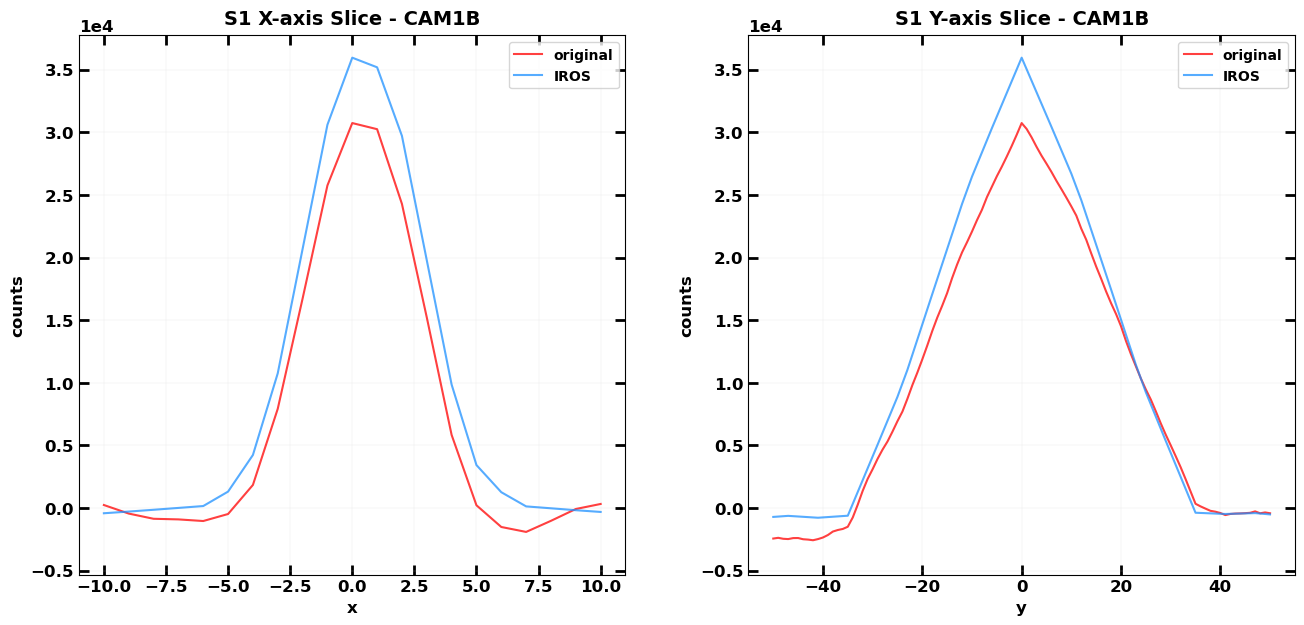

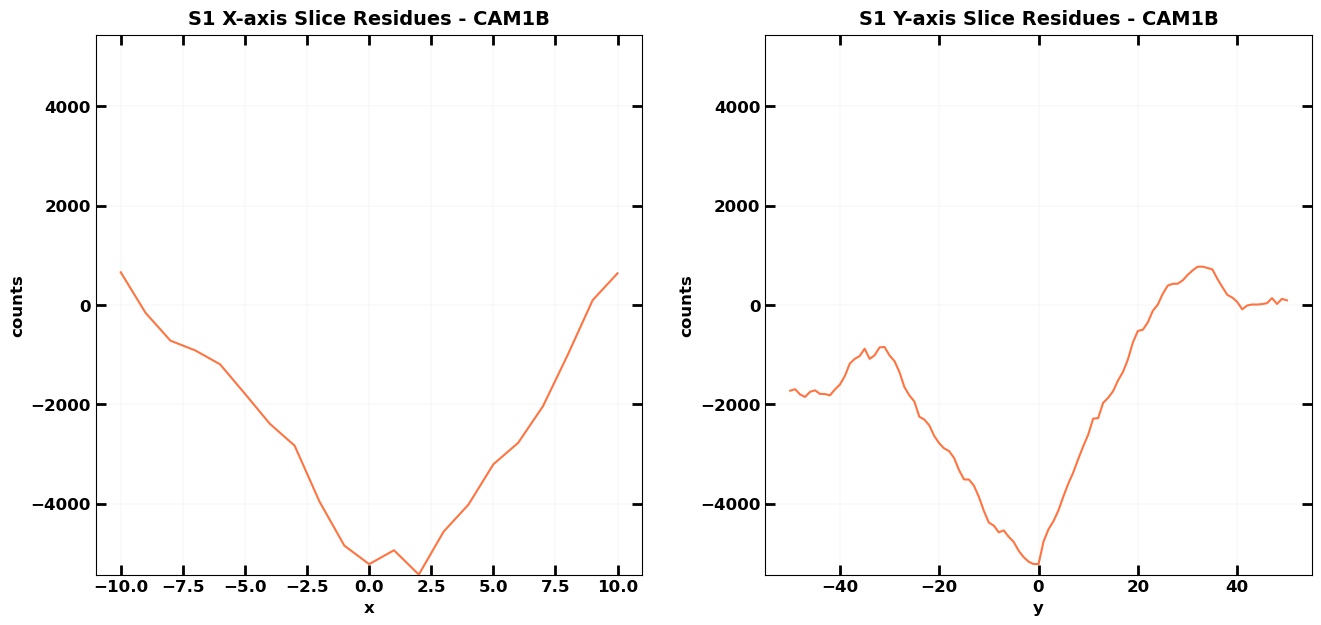

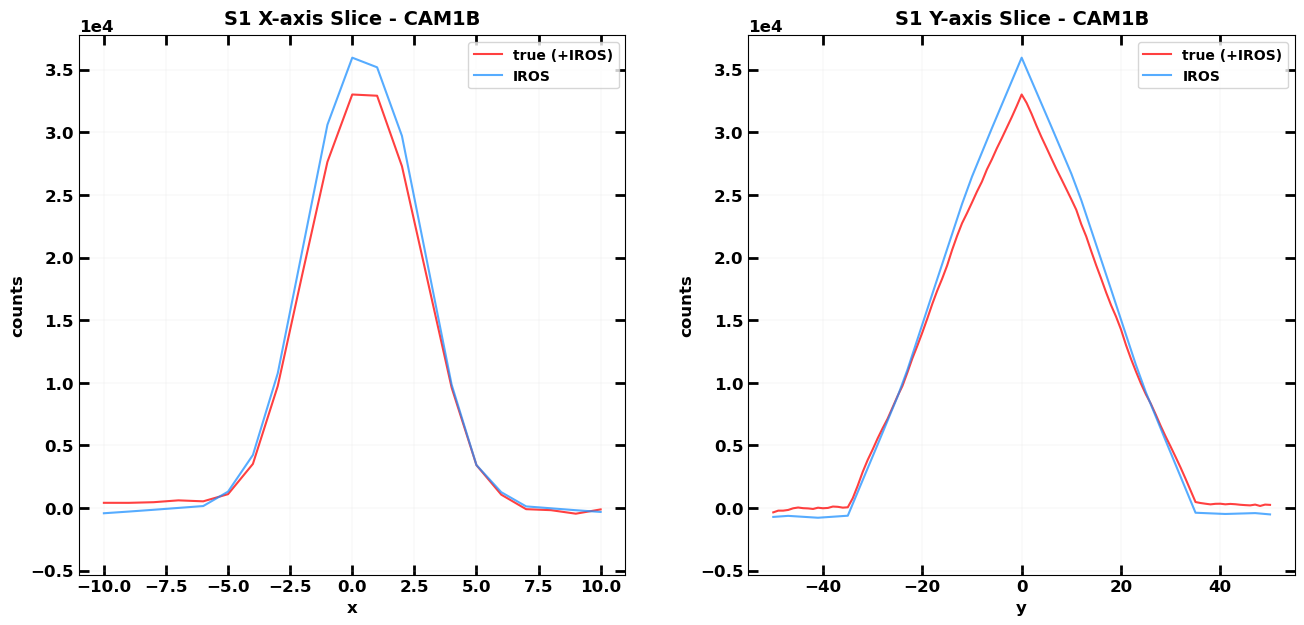

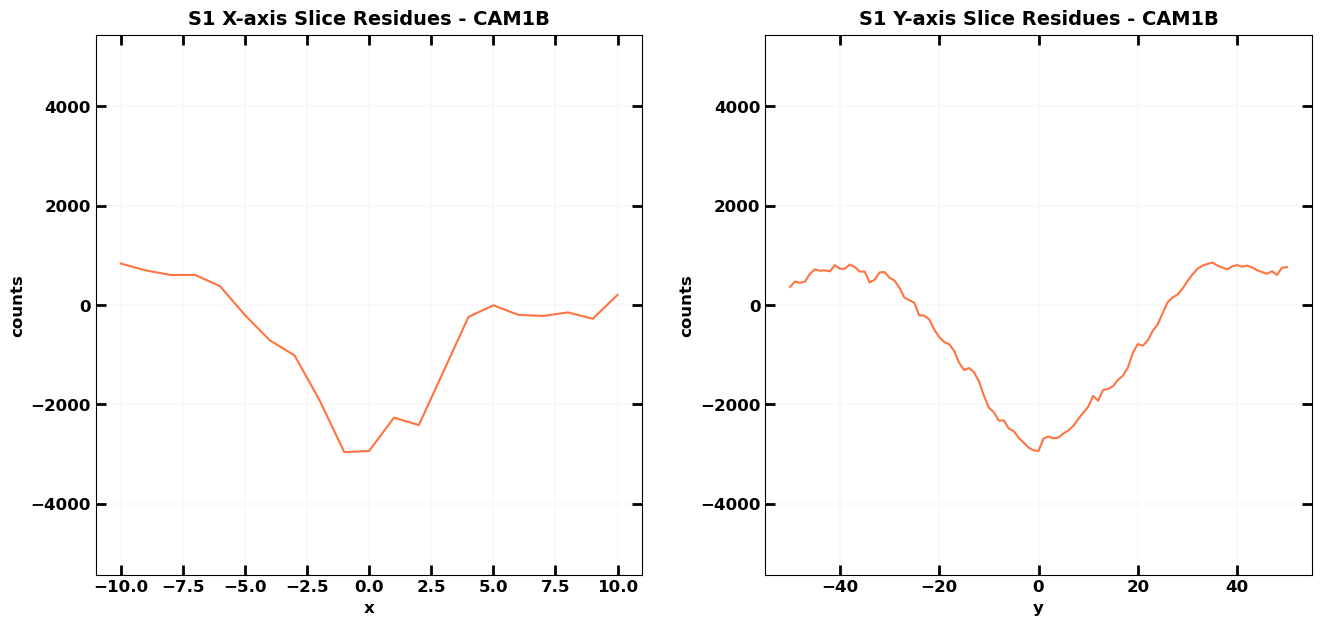

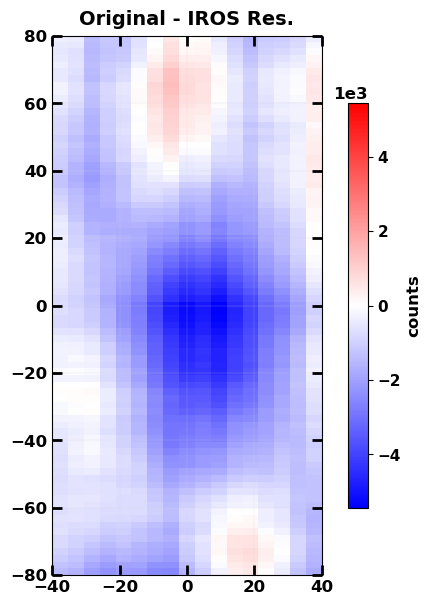

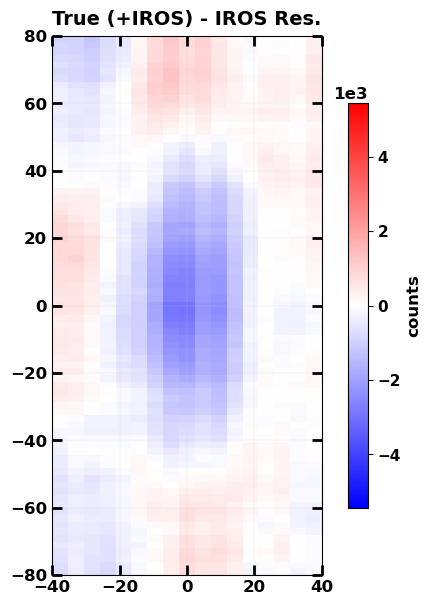

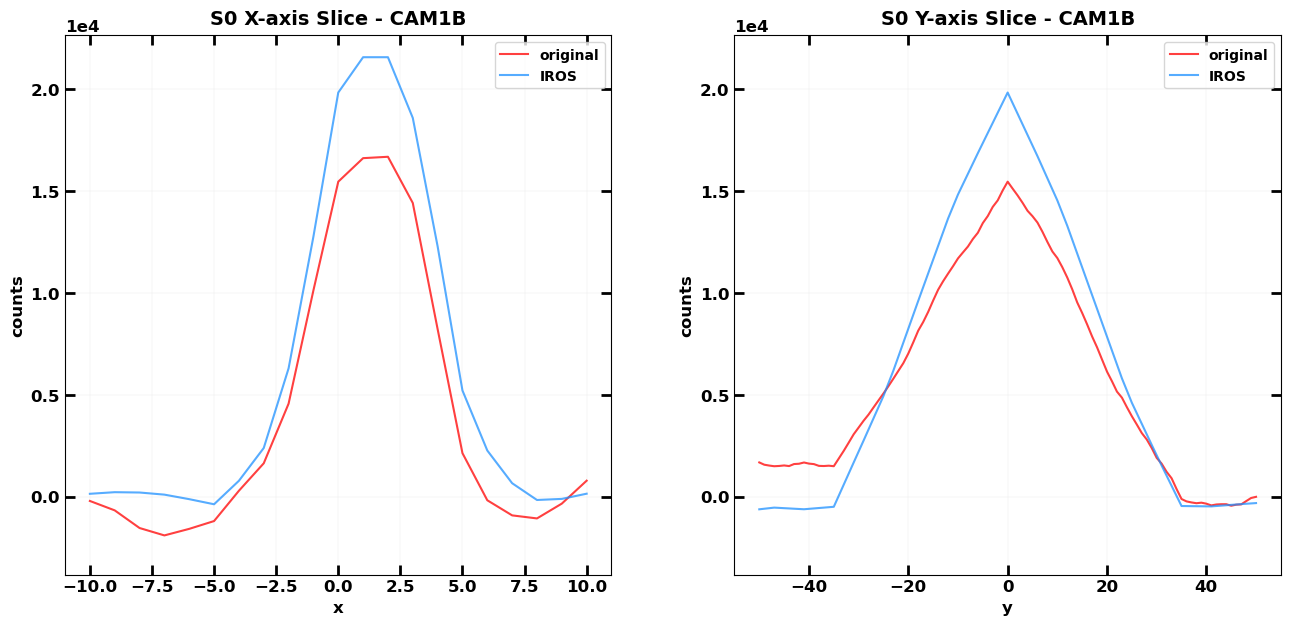

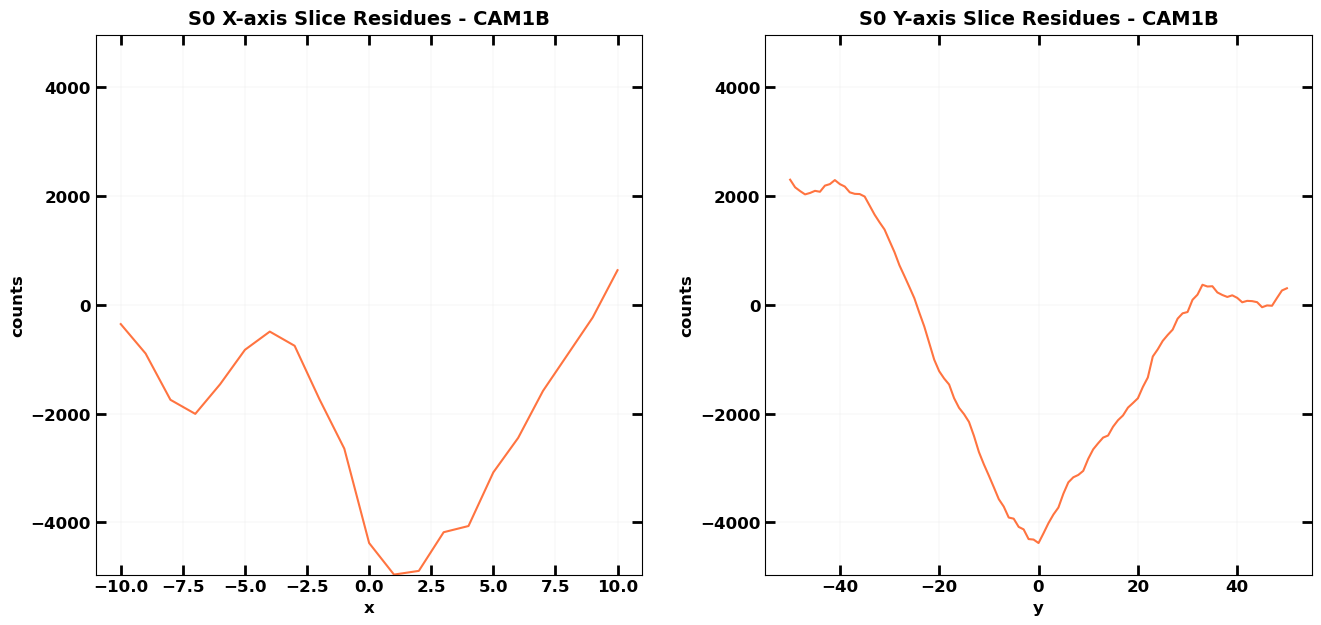

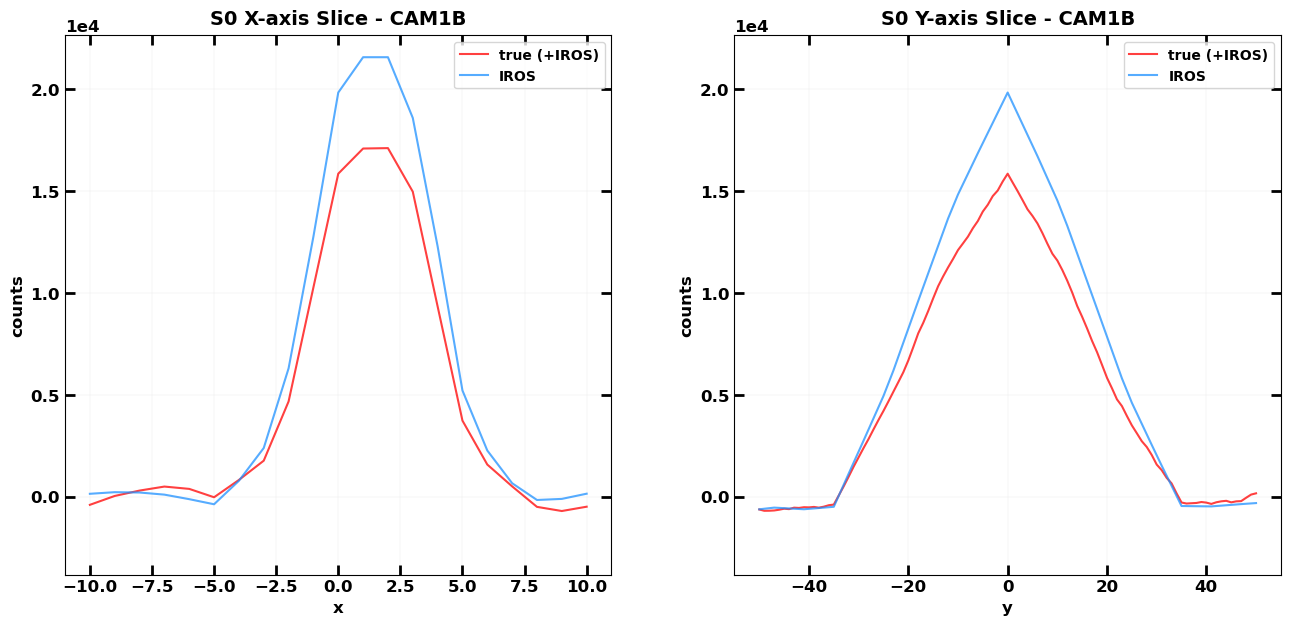

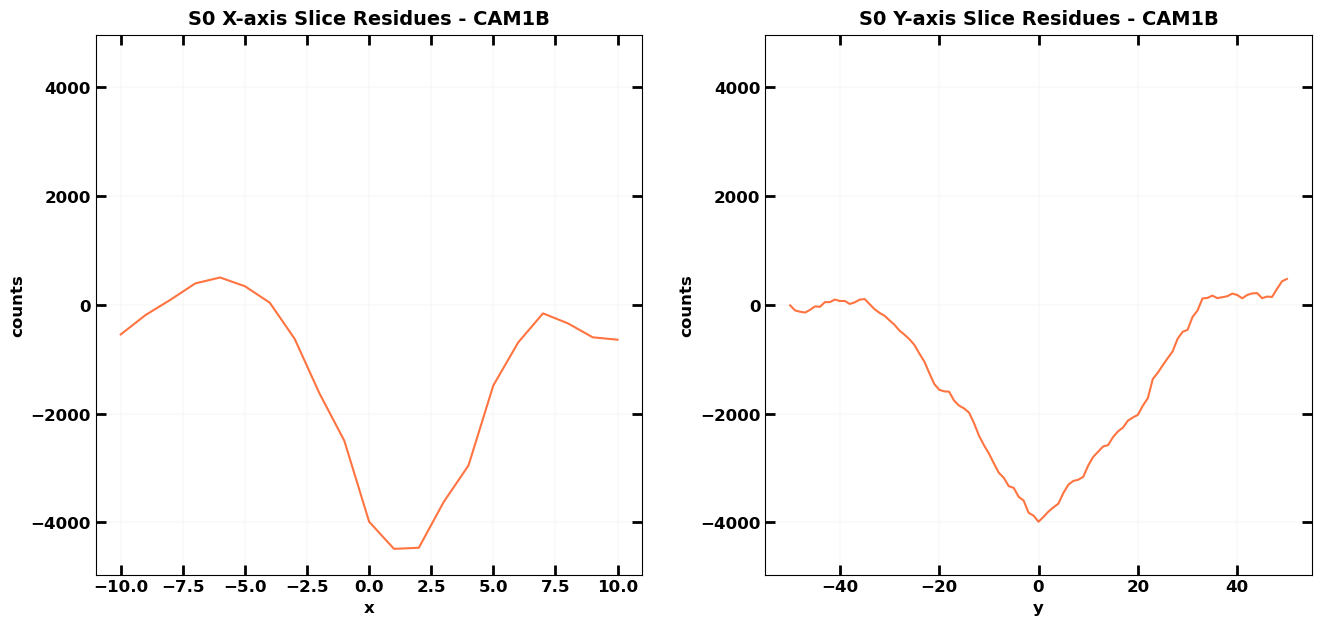

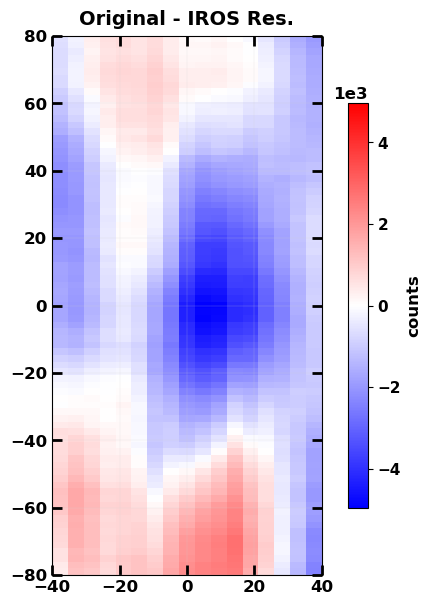

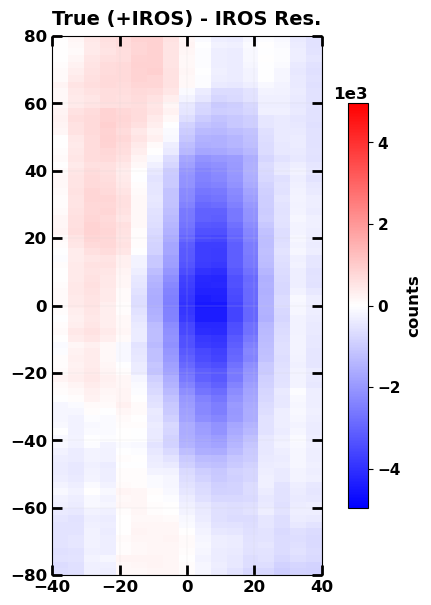

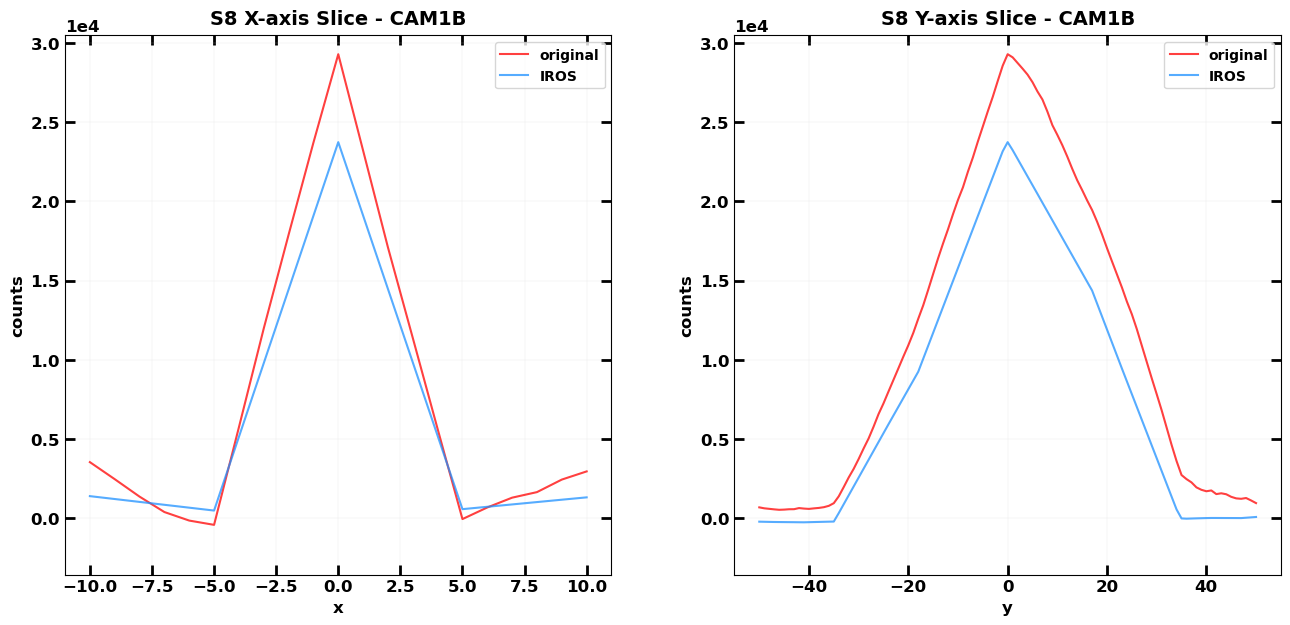

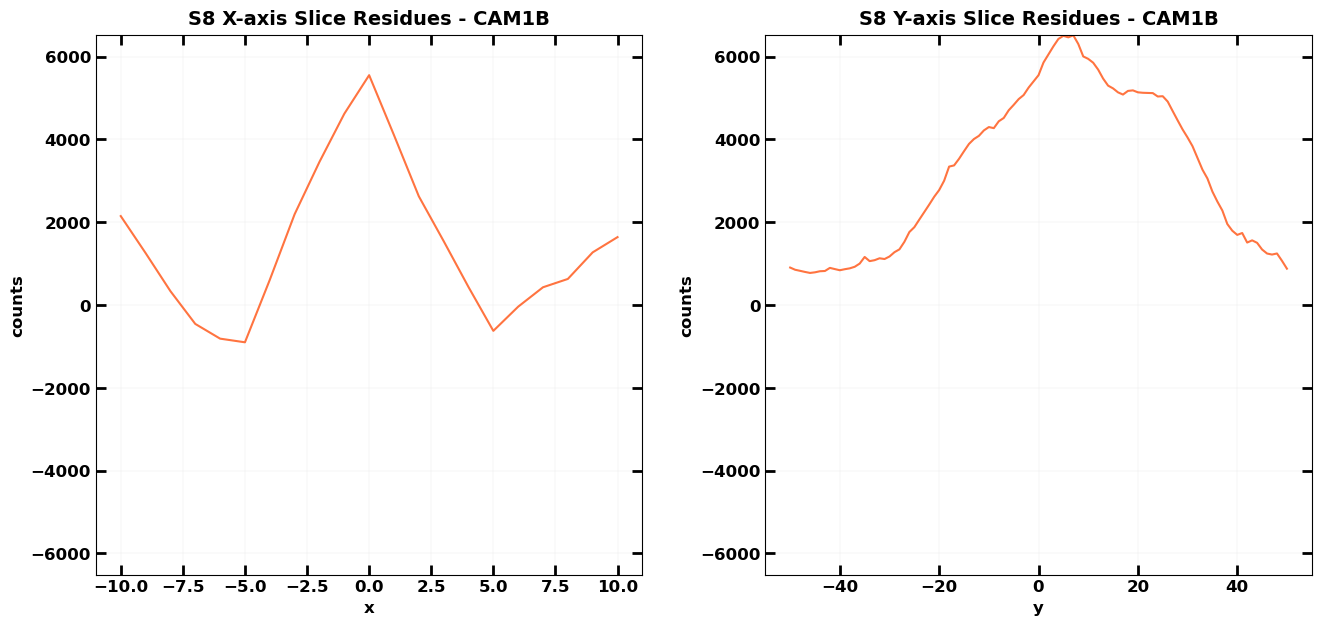

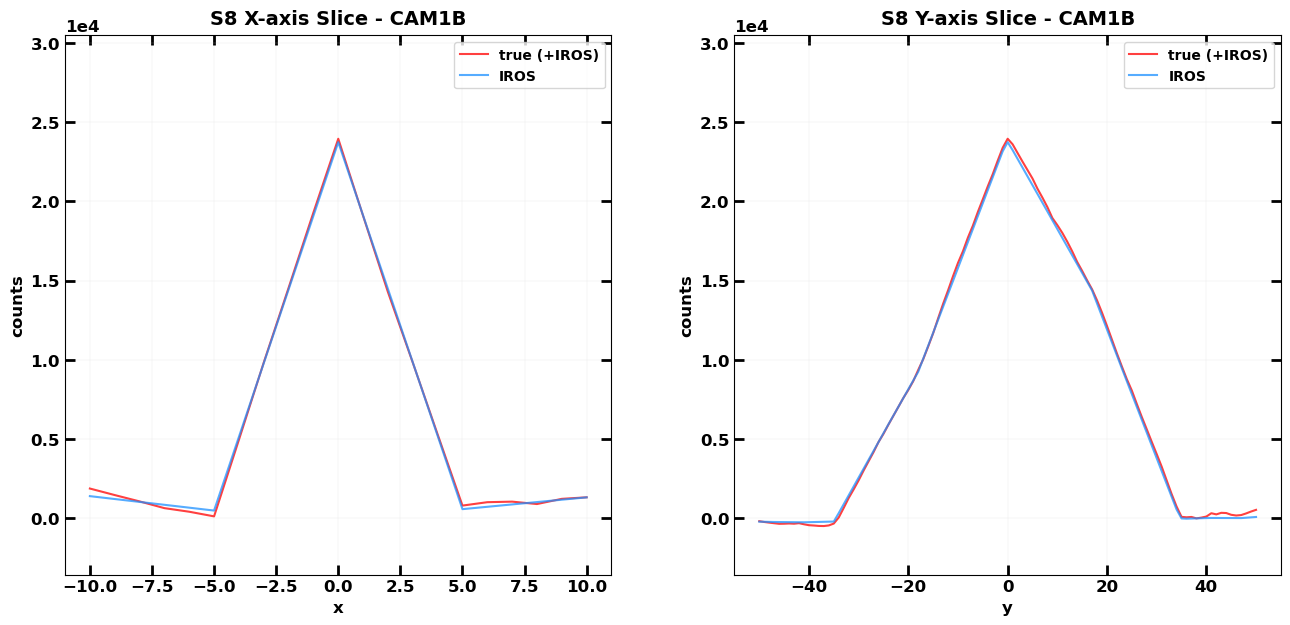

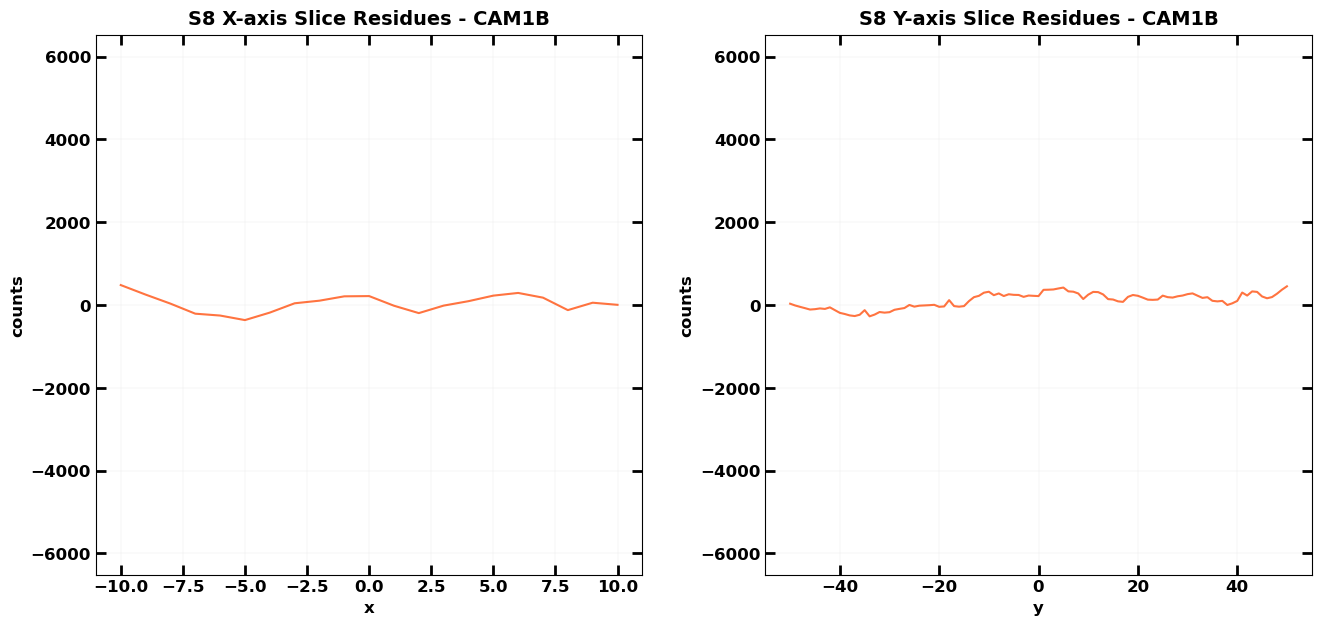

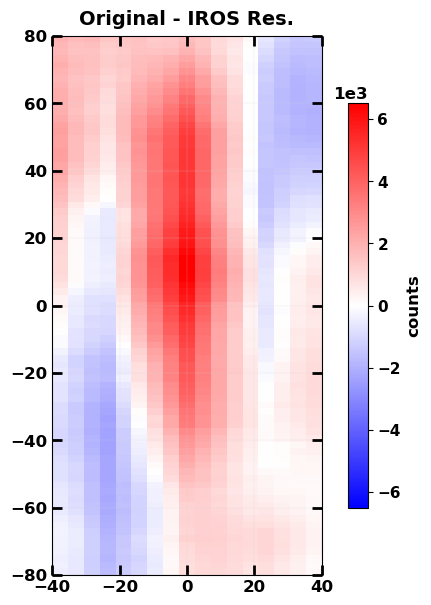

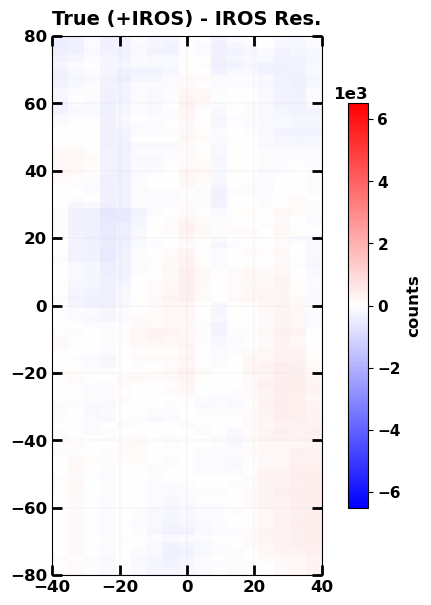

In [43]:
def plot_IROS_efficiency(
    data: dict,
    cameraID: str,
    true_sky: NDArray,
    crp: tuple[int, int],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> None:
    """
    
    """
    true_sky = true_sky.copy()
    true_sky_sub = true_sky.copy()
    UPX, UPY = camera.upscale_f

    for source, sx, sy, f, x, y in zip(
        data[cameraID]["catalog_name"]["data"],
        data[cameraID]["shift_x"]["data"],
        data[cameraID]["shift_y"]["data"],
        data[cameraID]["fluence"]["data"],
        data[cameraID]["x"]["data"],
        data[cameraID]["y"]["data"],
    ):
        # simulate source
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        _crp_true = true_sky[y - crp[0] : y + crp[0] + 1, x - crp[1] : x + crp[1] + 1]
        _crp_true_sub = true_sky_sub[y - crp[0] : y + crp[0] + 1, x - crp[1] : x + crp[1] + 1]
        _crp_modeled = modeled[y - crp[0] : y + crp[0] + 1, x - crp[1] : x + crp[1] + 1]
        _l = max(
            np.abs(_crp_true - _crp_modeled)[crp[0], :].max(),
            np.abs(_crp_true_sub - _crp_modeled)[crp[0], :].max(),
            np.abs(_crp_true - _crp_modeled)[:, crp[1]].max(),
            np.abs(_crp_true_sub - _crp_modeled)[:, crp[1]].max(),
        )
        COUNTS_LIMS = (
            min(_crp_true.min(), _crp_modeled.min()) - f // 20,
            max(_crp_true.max(), _crp_modeled.max()) + f // 20,
        )
        RES_LIMS = (-_l, _l)
        POS = (y, x)

        # plot true sky and source model
        enhance_slices(
            sky=[true_sky, modeled],
            label=[("original", "IROS")] * 2,
            pos=POS,
            crp=crp,
            source=source,
            cameraID=cameraID,
            offsety_first=[COUNTS_LIMS] * 2,
            offsety_second=[RES_LIMS] * 2,
            #save_to_first=save_path + "../models.png",
            #save_to_second=save_path + "../res.png",
        )
        enhance_slices(
            sky=[true_sky_sub, modeled],
            label=[("true (+IROS)", "IROS")] * 2,
            pos=POS,
            crp=crp,
            source=source,
            cameraID=cameraID,
            offsety_first=[COUNTS_LIMS] * 2,
            offsety_second=[RES_LIMS] * 2,
            #save_to_first=save_path + "../models.png",
            #save_to_second=save_path + "../res.png",
        )

        # plot heatmaps
        CUT = (40, 8)
        DPI = 100
        SCINOT = True

        true_cropped = iros.crop(
            image=true_sky,
            pos=POS,
            cropping=CUT,
        )
        true_sub_cropped = iros.crop(
            image=true_sky_sub,
            pos=POS,
            cropping=CUT,
        )
        modeled_cropped = iros.crop(
            image=modeled,
            pos=POS,
            cropping=CUT,
        )

        f_upy, f_upx = 2, 5
        image_plot(
            arr=upscale(true_cropped - modeled_cropped, f_upy, f_upx) * np.prod((f_upy, f_upx)),
            title="Original - IROS Res.",
            #xlabel="x",
            #ylabel="y",
            cbarlabel="counts",
            cmap="bwr",
            vmin=RES_LIMS[0],
            vmax=RES_LIMS[1],
            extent=(-CUT[1] * f_upx, CUT[1] * f_upx, -CUT[0] * f_upy, CUT[0] * f_upy),
            dpi=DPI,
            cbarscinot=SCINOT,
        )
        image_plot(
            arr=upscale(true_sub_cropped - modeled_cropped, f_upy, f_upx) * np.prod((f_upy, f_upx)),
            title="True (+IROS) - IROS Res.",
            #xlabel="x",
            #ylabel="y",
            cbarlabel="counts",
            cmap="bwr",
            vmin=RES_LIMS[0],
            vmax=RES_LIMS[1],
            extent=(-CUT[1] * f_upx, CUT[1] * f_upx, -CUT[0] * f_upy, CUT[0] * f_upy),
            dpi=DPI,
            cbarscinot=SCINOT,
        )

        # remove source from true
        true_sky_sub -= modeled


plot_IROS_efficiency(
    data=database,
    cameraID=cam_b,
    true_sky=simul_sky_camB,
    crp=(50, 10),
    camera=wfm,
    vignetting=True,
    psfy=False,
)

In [23]:
from mbloodmoon.io import simulation_files, simulation

dataset = 'detected'
filepaths = simulation_files(simul_data)

sdlA = simulation(filepaths[cam_a][dataset], energy_range=None, coords=None)
sdlB = simulation(filepaths[cam_b][dataset], energy_range=None, coords=None)

catalogA = simulation(filepaths[cam_a]["sources"])
catalogB = simulation(filepaths[cam_b]["sources"])

catalog_theta = get_catalog_theta(database, (catalogA, catalogB), (sdlA, sdlB), wfm)

# CAM1A
thetay_cam1a = database[cam_a]["theta_y"]["data"]
thetax_cam1a = database[cam_a]["theta_x"]["data"]

thetay_catalog_cam1a = catalog_theta[cam_a]["theta_y"]
thetax_catalog_cam1a = catalog_theta[cam_a]["theta_x"]


print(f"\n\n# - CAMERA {cam_a.upper()}\n")
for (idx, name), rtx, rty in zip(
    enumerate(database[cam_a]['catalog_name']['data'], start=1),
    60 * (thetax_cam1a - thetax_catalog_cam1a),
    60 * (thetay_cam1a - thetay_catalog_cam1a),
):
    print(
        f"  - Iter. {idx}, source: {name}\n"
        f"  - Residual theta X: {rtx} arcmin\n"
        f"  - Residual theta Y: {rty} arcmin\n"
    )

# Checking CAM1A...
# Checking CAM1B...


# - CAMERA CAM1A

  - Iter. 1, source: s4
  - Residual theta X: 3.204346497046426e-05 arcmin
  - Residual theta Y: -0.00032048104532010055 arcmin

  - Iter. 2, source: s5
  - Residual theta X: 0.04898478281358365 arcmin
  - Residual theta Y: -0.0003567355503079845 arcmin

  - Iter. 3, source: s3
  - Residual theta X: -5.324272041800777e-05 arcmin
  - Residual theta Y: -1.6038253091779353 arcmin

  - Iter. 4, source: s6
  - Residual theta X: 0.016220998498965855 arcmin
  - Residual theta Y: -0.0003931718752424667 arcmin

  - Iter. 5, source: s2
  - Residual theta X: -1.1810452424258647e-05 arcmin
  - Residual theta Y: 1.7361942910477524 arcmin

  - Iter. 6, source: s7
  - Residual theta X: -0.032339048699938644 arcmin
  - Residual theta Y: -0.0004296081970261715 arcmin

  - Iter. 7, source: s1
  - Residual theta X: -9.485076984554747e-05 arcmin
  - Residual theta Y: -2.3697983166839975 arcmin

  - Iter. 8, source: s0
  - Residual theta X: 0.0002

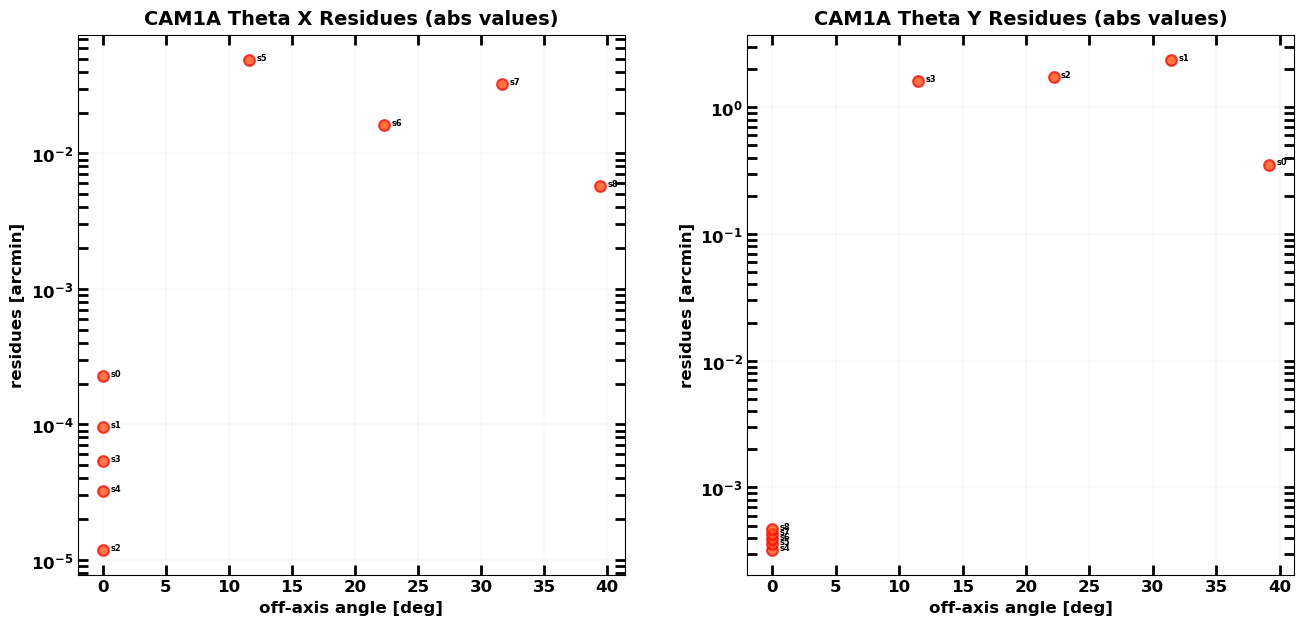

In [ ]:
import matplotlib as mpl

def _handle_subplots(nplots, spacing=0.27):
    """Creates and configures subplots."""
    size = 6
    fig_size = (size * nplots + 1, size) if nplots > 1 else (size, size)
    fig, axes = plt.subplots(1, nplots, figsize=fig_size)
    fig.tight_layout()
    fig.subplots_adjust(wspace=spacing * 5 / size)
    return fig, (axes if nplots > 1 else [axes])

def _set_labels(ax, xlabel, ylabel, title):
    """Configures labels and titles."""
    ax.set_xlabel(xlabel or "", fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel or "", fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, pad=8, fontweight='bold')

def _set_ticks(ax):
    """Configures grid and tick properties."""
    ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2, alpha=0.70)
    ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.ticklabel_format(scilimits=(-3, 4))

RCPARAMS = {
    'font.family': 'sans-serif',
    'font.weight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
}
PCAM = {
    "sourcename_fs": 6,
    "title_fs": 12,
    "title_pad": 8,
    "txt_fw": "bold",
    "txt_color": "black",
}
mpl.rcParams.update(RCPARAMS)


fig, axes = _handle_subplots(2)
for (i, ax), xval, yval, title in zip(
    enumerate(axes),
    (thetax_catalog_cam1a, thetay_catalog_cam1a),
    (60 * np.abs(thetax_cam1a - thetax_catalog_cam1a), 60 * np.abs(thetay_cam1a - thetay_catalog_cam1a)),
    (f'{cam_a.upper()} Theta X Residues (abs values)', f'{cam_a.upper()} Theta Y Residues (abs values)')
):
    fcolor, ecolor = ('OrangeRed', 'r')
    _set_labels(ax, 'off-axis angle [deg]', 'residues [arcmin]', title)
    _set_ticks(ax)
    ax.set_yscale('log')
    ax.scatter(xval, yval, c=fcolor, edgecolors=ecolor, s=60, alpha=0.75, linewidths=1.5)
    for idx, name in enumerate(database[cam_a]['catalog_name']['data']):
        ax.text(
            xval[idx] + 0.6, yval[idx], name, color=PCAM["txt_color"],
            fontsize=PCAM["sourcename_fs"], fontweight=PCAM["txt_fw"],
        )
plt.show()



from collections.abc import Sequence, Any

def biplot(
    y: Sequence[Sequence[Any], Sequence[Any]],
    titles: Sequence[str, str],
    x: Sequence[Sequence[Any], Sequence[Any]] | None = None,
    xlabel: Sequence[str, str] | None = None,
    ylabel: Sequence[str, str] | None = None,
    color: list[tuple[str, str]] | None = None,
) -> None:
    """
    """
    raise NotImplementedError




#fig, ax = plt.subplots(1, 1, figsize=(8, 8))
#ax.scatter(thetax_catalog_cam1a, 60 * np.abs(thetax_cam1a - thetax_catalog_cam1a))
#for idx, name in enumerate(database[cam_a]['catalog_name']['data']):
#    ax.text(
#        thetax_catalog_cam1a[idx] + 0.6, 60 * np.abs(thetax_cam1a - thetax_catalog_cam1a)[idx], name,
#        color=PCAM["txt_color"], fontsize=PCAM["sourcename_fs"], fontweight=PCAM["txt_fw"],
#    )
#ax.set_yscale('log')
#ax.set_ylabel('residues [arcmin]')
#ax.set_xlabel('off-axis angle [deg]')
#ax.set_title(f'{cam_a.upper()} Theta X Residues (abs values)')
#plt.show()
#
#
#fig, ax = plt.subplots(1, 1, figsize=(8, 8))
#ax.scatter(thetay_catalog_cam1a, 60 * np.abs(thetay_cam1a - thetay_catalog_cam1a))
#for idx, name in enumerate(database[cam_a]['catalog_name']['data']):
#    ax.text(
#        thetay_catalog_cam1a[idx] + 0.6, 60 * np.abs(thetay_cam1a - thetay_catalog_cam1a)[idx], name,
#        color=PCAM["txt_color"], fontsize=PCAM["sourcename_fs"], fontweight=PCAM["txt_fw"],
#    )
#ax.set_yscale('log')
#ax.set_ylabel('residues [arcmin]')
#ax.set_xlabel('off-axis angle [deg]')
#ax.set_title(f'{cam_a.upper()} Theta Y Residues (abs values)')
#plt.show()

In [ ]:
0it [00:00, ?it/s]FLUENCE START: 112576
1st OPTIMIZED FLUENCE: 112576
FINAL OPTIMIZED FLUENCE: 114169
FLUENCE START: 115681
1st OPTIMIZED FLUENCE: 115682
FINAL OPTIMIZED FLUENCE: 117157

1it [01:04, 64.01s/it]FLUENCE START: 100820.39449425548
1st OPTIMIZED FLUENCE: 100820.41002069895
FINAL OPTIMIZED FLUENCE: 101104.1041862436
FLUENCE START: 108621.61683344809
1st OPTIMIZED FLUENCE: 108621.8497301002
FINAL OPTIMIZED FLUENCE: 111093.77433160035

2it [02:29, 76.93s/it]FLUENCE START: 100856.10228053053
1st OPTIMIZED FLUENCE: 100856.35846684784
FINAL OPTIMIZED FLUENCE: 104359.4698355318
FLUENCE START: 98705.57910089572
1st OPTIMIZED FLUENCE: 98705.64896989135
FINAL OPTIMIZED FLUENCE: 101960.29718471642

3it [03:55, 80.97s/it]FLUENCE START: 78517.2009276104
1st OPTIMIZED FLUENCE: 78516.08302368027
FINAL OPTIMIZED FLUENCE: 71533.28756331753
FLUENCE START: 83230.86096190909
1st OPTIMIZED FLUENCE: 83231.59458636324
FINAL OPTIMIZED FLUENCE: 91554.75404499956

4it [05:10, 78.35s/it]FLUENCE START: 78371.03357555285
1st OPTIMIZED FLUENCE: 78371.70897584397
FINAL OPTIMIZED FLUENCE: 86017.85584638926
FLUENCE START: 60431.0084264064
1st OPTIMIZED FLUENCE: 60431.52079904104
FINAL OPTIMIZED FLUENCE: 64733.87282481051

5it [06:34, 80.61s/it]FLUENCE START: 40539.98280907196
1st OPTIMIZED FLUENCE: 40539.03957763091
FINAL OPTIMIZED FLUENCE: 36485.13561986782
FLUENCE START: 45286.982992142985
1st OPTIMIZED FLUENCE: 45287.90875633513
FINAL OPTIMIZED FLUENCE: 49816.699631968644

6it [07:42, 76.15s/it]FLUENCE START: 40350.12136471524
1st OPTIMIZED FLUENCE: 40351.13155394377
FINAL OPTIMIZED FLUENCE: 44386.24470933815
FLUENCE START: 33015.93460989951
1st OPTIMIZED FLUENCE: 33016.27813246137
FINAL OPTIMIZED FLUENCE: 35735.39444400113

7it [09:01, 77.27s/it]FLUENCE START: 23402.965632188207
1st OPTIMIZED FLUENCE: 23402.693533243135
FINAL OPTIMIZED FLUENCE: 22482.033976492294
FLUENCE START: 23935.986840553986
1st OPTIMIZED FLUENCE: 23932.619797993055
FINAL OPTIMIZED FLUENCE: 21539.35781819375

8it [10:15, 76.22s/it]FLUENCE START: 16016.402326252839
1st OPTIMIZED FLUENCE: 16015.754818068044
FINAL OPTIMIZED FLUENCE: 14934.763935623654
FLUENCE START: 23944.003282404206
1st OPTIMIZED FLUENCE: 23943.991641807625
FINAL OPTIMIZED FLUENCE: 23874.60163190533

In [40]:
print(
    f"#### Fluence Optimisation\n\n"
    f"# - CAM1A\n"
    f"-- it 1 (S4): 112576 --> 112576 --> 114169\n"
    f"-- it 2 (S5): 100820 --> 100820 --> 101104\n"
    f"-- it 3 (S3): 100856 --> 100856 --> 104359\n"
    f"-- it 4 (S6): 78517  -->  78516  --> 71533\n"
    f"-- it 5 (S2): 78371  -->  78372  --> 86018\n"
    f"-- it 6 (S7): 40540  -->  40539  --> 36485\n"
    f"-- it 7 (S1): 40350  -->  40351  --> 44386\n"
    f"-- it 8 (S0): 23403  -->  23403  --> 22482\n"
    f"-- it 9 (S8): 16016  -->  16016  --> 14935\n"
)


print(
    f"#### Fluence Optimisation\n\n"
    f"# - CAM1B\n"
    f"-- it 1 (S4): 115681 --> 115682 --> 117157\n"
    f"-- it 2 (S5): 108622 --> 108622 --> 111094\n"
    f"-- it 3 (S3):  98706 -->  98706 --> 101960\n"
    f"-- it 4 (S6):  83231 -->  83232 -->  91555\n"
    f"-- it 5 (S2):  60431 -->  60432 -->  64734\n"
    f"-- it 6 (S7):  45287 -->  45288 -->  49817\n"
    f"-- it 7 (S1):  33016 -->  33016 -->  35735\n"
    f"-- it 8 (S0):  23936 -->  23933 -->  21539\n"
    f"-- it 9 (S8):  23944 -->  23944 -->  23875\n"
)

#### Fluence Optimisation

# - CAM1A
-- it 1 (S4): 112576 --> 112576 --> 114169
-- it 2 (S5): 100820 --> 100820 --> 101104
-- it 3 (S3): 100856 --> 100856 --> 104359
-- it 4 (S6): 78517  -->  78516  --> 71533
-- it 5 (S2): 78371  -->  78372  --> 86018
-- it 6 (S7): 40540  -->  40539  --> 36485
-- it 7 (S1): 40350  -->  40351  --> 44386
-- it 8 (S0): 23403  -->  23403  --> 22482
-- it 9 (S8): 16016  -->  16016  --> 14935

#### Fluence Optimisation

# - CAM1B
-- it 1 (S4): 115681 --> 115682 --> 117157
-- it 2 (S5): 108622 --> 108622 --> 111094
-- it 3 (S3):  98706 -->  98706 --> 101960
-- it 4 (S6):  83231 -->  83232 -->  91555
-- it 5 (S2):  60431 -->  60432 -->  64734
-- it 6 (S7):  45287 -->  45288 -->  49817
-- it 7 (S1):  33016 -->  33016 -->  35735
-- it 8 (S0):  23936 -->  23933 -->  21539
-- it 9 (S8):  23944 -->  23944 -->  23875

